# CORRELATIONS IN VLP

This file will be used to rough perform the VLP correlations and build functions for them. Given question is tubing OD of 2 7/8" nad ID of 2.441". Casing ID is 5 1/2". GOR is 1000, Ql = 20 m3/day. Pe = 120 kg/cm2 and Pwf = 100 kg/cm2

## INDEX

1. [PVT](#1)
2. [Hagedron-Brown](#2)
3. [Beggs and Brill](#3)
4. [Duns and Ros](#4)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

<a name = "1"></a>
## PVT

In [ ]:
import numpy as np


class BlackOilPVT:
    """
    A comprehensive Black Oil PVT calculator using standard industry empirical correlations
    (Standing, Beggs-Robinson, Lee-Gonzalez-Eakin, Dranchuk-Abou-Kassem).
    Assumes standard US Oilfield Units.
    """

    def __init__(self, sg_gas=0.65, sg_oil=0.84, oil_api=None, sg_water=1.03, watercut=0.0):
        """
        Initializes the fluid with its constant surface properties.

        Args:
            sg_gas (float): Specific gravity of gas (Air = 1.0).
            sg_oil (float): Specific gravity of oil (Water = 1.0).
            oil_api (float, optional): Oil API gravity. Overrides sg_oil if provided.
            sg_water (float, optional): Specific gravity of water. Defaults to 1.03.
            watercut (float): Watercut as a decimal fraction (0.0 to 1.0).
        """
        self.sg_g = sg_gas
        self.sg_o = 141.5 / (131.5 + oil_api) if oil_api else sg_oil
        self.sg_w = sg_water
        self.wc = watercut

        # BUG FIX 1: Guard against division by zero at watercut = 1.0.
        # wor = wc / (1 - wc) blows up at full water production.
        self.wor = watercut / max(1.0 - watercut, 1e-9)

        # Calculate API gravity (used in almost all oil correlations)
        self.api = (141.5 / self.sg_o) - 131.5

    def get_pseudo_critical(self):
        """
        Calculates Sutton's pseudo-critical temperature and pressure for natural gas.

        Returns:
            tuple:
                Tpc (float): Pseudo-critical temperature in Rankine (°R).
                Ppc (float): Pseudo-critical pressure in psia.
        """
        Tpc = 187 + 330 * self.sg_g - 71.5 * self.sg_g**2
        Ppc = 667 + 15 * self.sg_g - 37.5 * self.sg_g**2
        return Tpc, Ppc

    def calculate_dak_z_factor(self, P, T, gamma_g, max_iter=100, tolerance=1e-6):
        """
        Calculates the Gas Z-factor using the Dranchuk-Abou-Kassem (DAK)
        equation of state for dry natural gas via Newton-Raphson iteration.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            gamma_g (float): Gas specific gravity.
            max_iter (int, optional): Maximum iterations for the solver. Defaults to 100.
            tolerance (float, optional): Convergence tolerance. Defaults to 1e-6.

        Returns:
            float: Gas compressibility factor (Z-factor), dimensionless.
        """
        T_r = T + 459.67
        Tpc, Ppc = self.get_pseudo_critical()
        Tpr = T_r / Tpc
        Ppr = P / Ppc

        A1, A2, A3 = 0.3265, -1.0700, -0.5339
        A4, A5, A6 = 0.01569, -0.05165, 0.5475
        A7, A8, A9 = -0.7361, 0.1844, 0.1056
        A10, A11 = 0.6134, 0.7210

        c1 = A1 + A2/Tpr + A3/(Tpr**3) + A4/(Tpr**4) + A5/(Tpr**5)
        c2 = A6 + A7/Tpr + A8/(Tpr**2)
        c3 = A9 * (A7/Tpr + A8/(Tpr**2))
        c4 = A10 / (Tpr**3)

        rho_r = 0.27 * Ppr / Tpr

        for i in range(max_iter):
            term_exp = np.exp(-A11 * (rho_r**2))

            f = (1.0 + c1*rho_r + c2*(rho_r**2) - c3*(rho_r**5) +
                 c4*(rho_r**2)*(1.0 + A11*(rho_r**2))*term_exp - (0.27 * Ppr / (rho_r * Tpr)))

            # BUG FIX 2: The analytical derivative of the DAK EOS c4 term was wrong.
            # Differentiating c4*rho^2*(1 + A11*rho^2)*exp(-A11*rho^2) w.r.t. rho gives:
            #   2*c4*rho*(1 + A11*rho^2 - A11^2*rho^4)*exp(-A11*rho^2)
            # The original code contained a spurious -A11*rho^3 term inside the bracket,
            # which caused Newton-Raphson to converge to a slightly wrong root.
            df = (c1 + 2.0*c2*rho_r - 5.0*c3*(rho_r**4) +
                  2.0*c4*rho_r*(1.0 + A11*(rho_r**2) - A11**2*(rho_r**4))*term_exp +
                  (0.27 * Ppr / ((rho_r**2) * Tpr)))

            rho_r_new = rho_r - f / df

            if abs(rho_r_new - rho_r) < tolerance:
                z_factor = 0.27 * Ppr / (rho_r_new * Tpr)
                return round(z_factor, 4)

            rho_r = rho_r_new

        raise ValueError("Z-factor solver did not converge. Check input parameters.")

    def calc_bubble_point(self, T, Rsb):
        """
        Calculates Bubble Point Pressure (Pb) using Standing's Correlation.

        Args:
            T (float): Local temperature in Fahrenheit (°F).
            Rsb (float): Solution GOR at bubble point (Initial Producing GOR) in scf/STB.

        Returns:
            float: Bubble point pressure in psia.
        """
        a = 0.00091 * T - 0.0125 * self.api
        pb = 18.2 * (((Rsb / self.sg_g) ** 0.83) * (10 ** a) - 1.4)
        return max(pb, 14.7)

    def calc_rs(self, P, T, Pb, Rsb):
        """
        Calculates Solution Gas-Oil Ratio (Rs) using Standing's Correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Pb (float): Bubble point pressure in psia.
            Rsb (float): Solution GOR at bubble point in scf/STB.

        Returns:
            float: Solution Gas-Oil Ratio in scf/STB.
        """
        if P >= Pb:
            return Rsb
        a = 0.00091 * T - 0.0125 * self.api
        rs = self.sg_g * (((P / 18.2) + 1.4) * (10 ** -a)) ** 1.2048
        return max(rs, 0.0)

    def calc_bo(self, P, T, Rs, Pb):
        """
        Calculates Oil Formation Volume Factor (Bo) using Standing's Correlation.
        Includes simplified Vasquez-Beggs isothermal compressibility for undersaturated conditions.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Pb (float): Bubble point pressure in psia.

        Returns:
            float: Oil Formation Volume Factor (Bo) in bbl/STB.
        """
        F = Rs * np.sqrt(self.sg_g / self.sg_o) + 1.25 * T
        bo_sat = 0.9759 + 0.00012 * (F ** 1.175)

        if P <= Pb:
            return bo_sat

        co = (5 * Rs + 17.2 * T - 1180 * self.sg_g + 12.61 * self.api - 1433) / (P * 10**5)
        co = max(co, 5e-6)
        bo_under = bo_sat * np.exp(-co * (P - Pb))
        return bo_under

    def calc_bg(self, P, T, Z):
        """
        Calculates Gas Formation Volume Factor (Bg) using the Real Gas Law.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: Gas Formation Volume Factor (Bg) in ft³/scf.
        """
        T_rankine = T + 460.0
        bg = 0.02827 * Z * T_rankine / P
        return bg

    def calc_bw(self, P, T):
        """
        Calculates Water Formation Volume Factor (Bw) using polynomial approximation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water Formation Volume Factor (Bw) in bbl/STB.
        """
        delta_T = T - 60.0
        bw = 1.0 + 1.2e-4 * delta_T + 1e-6 * (delta_T ** 2) - 3.33e-6 * P
        return max(bw, 0.9)

    def calc_density_oil(self, Rs, Bo):
        """
        Calculates in-situ Oil Density.

        Args:
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Bo (float): Oil Formation Volume Factor at local pressure in bbl/STB.

        Returns:
            float: In-situ oil density in lbm/ft³.
        """
        rho_o_insitu = (350.0 * self.sg_o + 0.0764 * self.sg_g * Rs) / (5.615 * Bo)
        return rho_o_insitu

    def calc_density_gas(self, P, T, Z):
        """
        Calculates in-situ Gas Density using the Real Gas Law.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: In-situ gas density in lbm/ft³.
        """
        T_rankine = T + 460.0
        rho_g_insitu = 28.967 * self.sg_g * P / (Z * 10.732 * T_rankine)
        return rho_g_insitu

    def calc_viscosity_oil(self, P, T, Rs, Pb):
        """
        Calculates Oil Viscosity using Beggs-Robinson Correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Pb (float): Bubble point pressure in psia.

        Returns:
            float: Oil viscosity in centipoise (cp).
        """
        z = 3.0324 - 0.02023 * self.api
        y = 10 ** z
        x = y * (T ** -1.163)
        mu_od = 10 ** x - 1.0

        a = 10.715 * ((Rs + 100) ** -0.515)
        b = 5.44 * ((Rs + 150) ** -0.338)
        mu_os = a * (mu_od ** b)

        if P <= Pb:
            return mu_os

        m = 2.6 * (P ** 1.187) * np.exp(-11.513 - 8.98e-5 * P)
        mu_o_under = mu_os * ((P / Pb) ** m)
        return mu_o_under

    def calc_viscosity_gas(self, P, T, Z):
        """
        Calculates Gas Viscosity using the Lee-Gonzalez-Eakin correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: Gas viscosity in centipoise (cp).
        """
        T_rankine = T + 460.0
        Mg = 28.97 * self.sg_g
        rho_g = self.calc_density_gas(P, T, Z) / 62.4

        K = (9.379 + 0.01607 * Mg) * (T_rankine ** 1.5) / (209.2 + 19.26 * Mg + T_rankine)
        X = 3.448 + (986.4 / T_rankine) + 0.01009 * Mg
        Y = 2.447 - 0.2224 * X

        mu_g = 1e-4 * K * np.exp(X * (rho_g ** Y))
        return mu_g

    def calc_viscosity_water(self, T):
        """
        Calculates water viscosity using the Brill & Beggs correlation.

        Args:
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water viscosity in centipoise (cp).
        """
        return np.exp(1.003 - 0.01479 * T + 0.00001982 * T**2)

    def calc_surface_tension_oil(self, P, T):
        """
        Calculates Liquid-Gas Surface Tension for oil using Baker-Swerdloff.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Oil surface tension in dynes/cm.
        """
        sigma_68 = 39.0 - 0.2571 * self.api
        sigma_100 = 37.5 - 0.2571 * self.api

        if T > 100:
            sigma_dead = sigma_100 - (T - 100) * 0.05
        else:
            sigma_dead = sigma_68 - (T - 68) * ((sigma_68 - sigma_100) / 32.0)

        sigma_dead = max(sigma_dead, 1.0)
        sigma_live = sigma_dead * np.exp(-0.0002 * P)
        return max(sigma_live, 1.0)

    def calc_surface_tension_water(self, T):
        """
        Calculates Water-Gas Surface Tension.

        Args:
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water surface tension in dynes/cm.
        """
        sigma_w = 75.0 - 0.116 * T
        return max(sigma_w, 40.0)

    def calc_M(self, gor):
        """
        Calculates the mixture molecular weight proxy M used in the H-B friction Re number.

        Args:
            gor (float): Solution Gas-Oil Ratio at current pressure in scf/STB oil.

        Returns:
            float: M (lbm/STB liquid), dimensionless in context of Re formula.
        """
        # BUG FIX 4: GLR conversion was wrong. GLR (gas per STB *liquid*) equals
        # GOR (gas per STB *oil*) multiplied by the oil fraction (1 - wc), i.e.:
        #   glr = gor * (1 - wc) = gor / (1 + wor)
        # The original code used gor / (1 + wc), which is dimensionally incorrect
        # and over-estimates GLR at any nonzero watercut.
        glr = gor / (1.0 + self.wor)
        return (self.sg_o * 350.52 / (1 + self.wor)
                + self.sg_w * 350.52 * self.wor / (1 + self.wor)
                + self.sg_g * 0.0764 * glr)
    
    def rsb_from_test(self, Rs_test, Pwf_test, Pb, T):
        """
        Calculates bubble-point gor from test data.
        Args:
            Rs_test: GOR at test condition, scf/stb
            Pwf_test: Wellbore pressure at test condition, psia
            Pb: Bubble-point pressure, psia
            T: Test temperature, Farenheit
        Returns:
            Rsb: GOR at bubble-point, scf/stb
        """
        if Pwf_test >= Pb:
            return Rs_test          # test point already saturated -> Rs_test IS Rsb
        a = 0.00091 * T - 0.0125 * self.api
        shape_at_test = self.sg_g * (((Pwf_test / 18.2) + 1.4) * (10 ** -a)) ** 1.2048
        shape_at_pb   = self.sg_g * (((Pb / 18.2) + 1.4) * (10 ** -a)) ** 1.2048
        return Rs_test * (shape_at_pb / shape_at_test)

    def fluid_properties_dict(self, P, T, Rsb, Pb=0):
        """
        Calculates all fluid properties at a specific pressure and temperature node.
        Correctly blends oil and water properties based on in-situ volume fractions.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rsb (float): Initial producing Gas-Oil Ratio in scf/STB.
            Pb (float): Bubble-point pressure in psia. Calculated if 0.

        Returns:
            dict: A dictionary containing all blended liquid and gas properties required
                  by multiphase flow correlations like Hagedorn-Brown.
        """
        Pb = self.calc_bubble_point(T, Rsb) if Pb == 0 else Pb

        Rs = self.calc_rs(P, T, Pb, Rsb)
        Z = self.calculate_dak_z_factor(P, T, self.sg_g)
        M = self.calc_M(Rs)

        Bo = self.calc_bo(P, T, Rs, Pb)
        Bw = self.calc_bw(P, T)
        Bg = self.calc_bg(P, T, Z)

        # Surface volume fractions (used for viscosity and surface tension blending,
        # consistent with H-B correlation literature)
        fo = 1.0 / (1.0 + self.wor)
        fw = self.wor / (1.0 + self.wor)

        # In-situ volume fractions (used for density blending)
        # These account for the reservoir FVF of each phase.
        total_res_vol = Bo + self.wor * Bw
        fo_insitu = Bo / total_res_vol
        fw_insitu = (self.wor * Bw) / total_res_vol

        # Pure phase properties
        rho_o = self.calc_density_oil(Rs, Bo)
        rho_w = 62.4 * self.sg_w / Bw
        mu_o = self.calc_viscosity_oil(P, T, Rs, Pb)
        mu_w = self.calc_viscosity_water(T)
        sigma_o = self.calc_surface_tension_oil(P, T)
        sigma_w = self.calc_surface_tension_water(T)

        rho_l = rho_o * fo_insitu + rho_w * fw_insitu

        # Viscosity and surface tension: blended with surface fractions per H-B convention
        mu_l = mu_o * fo + mu_w * fw
        sigma_l = sigma_o * fo + sigma_w * fw

        return {
            "M": M,
            "Pb": Pb,
            "Rsb": Rsb,
            "gor": Rs,
            "glr": Rsb / (1.0 + self.wor),
            "rho_l": rho_l,
            "rho_g": self.calc_density_gas(P, T, Z),
            "mu_l": mu_l,
            "mu_g": self.calc_viscosity_gas(P, T, Z),
            "sigma_l": sigma_l,
            "Bo": Bo,
            "Bg": Bg,   # ft³/scf
            "Bw": Bw,
            "Pr": P,
            "Tr": T,
            "Z": Z,
        }

<a name = "2"></a>
## HAGEDRON-BROWN


In [15]:
import numpy as np
import matplotlib.pyplot as plt


class HagedornBrown:
    """
    Calculates multiphase flow pressure gradients and VLP curves for vertical wellbores
    using the Hagedorn-Brown correlation and a coupled Black Oil PVT model.
    Includes Griffith-Wallis bubble flow detection and holdup correction.
    """

    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model,
                 fluid_properties, watercut=0.0, theta=0.0):
        self.tid      = tubing_id #ft
        self.tod      = tubing_od #ft
        self.cid      = casing_id #ft
        self.roughness = roughness #ft
        self.pvt_model = pvt_model 
        self.wc       = watercut #ratio
        self.wor      = watercut / (1.0 - watercut + 1e-9)
        self.theta    = np.radians(theta) #degrees
        self.Ap       = (np.pi / 4.0) * self.tid**2
        self.Pb       = pvt_model.calc_bubble_point
        self.fp       = fluid_properties #{"M","Pb","Rsb","gor","glr","rho_l","rho_g","mu_l","mu_g","sigma_l","Bo","Bg","Bw","Pr","Tr","Z",}

    # ------------------------------------------------------------------
    # Fluid property update
    # ------------------------------------------------------------------

    def update_fluid_properties(self, P, T, Ql):
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(
            P, T, self.fp["Rsb"], self.fp["Pb"]
        )

    # ------------------------------------------------------------------
    # Hagedorn-Brown dimensionless groups
    # ------------------------------------------------------------------

    def dimensionless_numbers(self):
        """
        Calculates the required Hagedorn-Brown dimensionless groups and
        sets Vsl, Vsg, Vm in self.fp.

        Returns:
            tuple: Nl, CNl, Nlv, Ngv, Nd (all dimensionless).
        """
        fo = 1.0 / (1.0 + self.wor)
        fw = self.wor  / (1.0 + self.wor)

        # In-situ liquid volumetric rate  [ft³/day]
        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"]  = q_liquid_insitu / (86400.0 * self.Ap)

        # ----------------------------------------------------------------
        # BUG FIX — free gas calculation
        # ----------------------------------------------------------------
        # fp["glr"] must be the TOTAL surface producing GLR (scf / STB liquid),
        # derived from Rsb (initial GOR), NOT from Rs (dissolved GOR at local P).
        #
        # The PVT dict previously stored glr = Rs/(1+wor), which equals gor*fo
        # at every pressure, making free_gas_scf = Ql*(glr - gor*fo) = 0 always.
        # With Vsg = 0 there is no gas phase: holdup = 1, mixture density =
        # liquid density at every rate, and the only gradient that changes with
        # rate is friction (∝ Vm²). That produces the monotonically-increasing
        # Pwf curve seen in the plot — the U-shape requires gas gravity relief
        # to dominate at low rates, which only appears when free gas is non-zero.
        #
        # Fix applied in BlackOilPVT.fluid_properties_dict:
        #   "glr": Rsb / (1 + wor)   ← total surface GLR, constant with P
        #   "gor": Rs                 ← dissolved portion, decreases below Pb
        # Now below bubble point:  glr > gor*fo  =>  free_gas_scf > 0  ✓
        # ----------------------------------------------------------------
        free_gas_scf   = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu   = (free_gas_scf
                          * (14.7 / self.fp["Pr"])
                          * ((self.fp["Tr"] + 460.0) / 520.0)
                          * self.fp["Z"])
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)
        self.fp["Vm"]  = self.fp["Vsl"] + self.fp["Vsg"]

        # H-B dimensionless groups
        base_term = 1.0 / (self.fp["rho_l"] * self.fp["sigma_l"] ** 3)
        Nl  = 0.15726 * self.fp["mu_l"] * (base_term ** 0.25)
        CNl = 0.061 * Nl**3 - 0.0929 * Nl**2 + 0.0505 * Nl + 0.0019

        Nlv = 1.938 * self.fp["Vsl"] * (self.fp["rho_l"] / self.fp["sigma_l"]) ** 0.25
        Ngv = 1.938 * self.fp["Vsg"] * (self.fp["rho_l"] / self.fp["sigma_l"]) ** 0.25
        Nd  = 120.872 * self.tid     * (self.fp["rho_l"] / self.fp["sigma_l"]) ** 0.5

        return Nl, CNl, Nlv, Ngv, Nd

    # ------------------------------------------------------------------
    # Bubble-flow regime detection  (Griffith & Wallis, 1961)
    # ------------------------------------------------------------------

    def is_bubble_flow(self):
        """
        Determines whether the current flow conditions fall in the bubble-flow
        regime using the Griffith-Wallis criterion.

        Bubble flow exists when the in-situ gas void fraction (λg = Vsg/Vm)
        is less than the boundary value LB:
            LB = max(0.25,  1.071 − 0.2218 · Vm² / d)

        Velocities must be computed by dimensionless_numbers() before calling
        this method (they are stored in self.fp).

        Returns:
            bool: True if bubble flow, False otherwise.
        """
        Vm  = self.fp.get("Vm",  0.0)
        Vsg = self.fp.get("Vsg", 0.0)

        if Vm <= 1e-9:
            return False

        # Griffith-Wallis bubble-flow boundary
        LB = 1.071 - 0.2218 * (Vm ** 2) / self.tid
        LB = max(LB, 0.25)

        lambda_g = Vsg / Vm          # in-situ gas void fraction (no-slip)
        return lambda_g < LB

    # ------------------------------------------------------------------
    # Griffith holdup for bubble flow
    # ------------------------------------------------------------------

    def griffith_holdup(self):
        """
        Calculates liquid holdup for bubble-flow regime using the
        Griffith-Wallis correlation and updates mixture properties in self.fp.

        The bubble-rise velocity Vs = 0.8 ft/s is a standard field-unit
        constant for oil–gas systems.

        Quadratic form (Griffith & Wallis):
            Vs·Hl² − (Vm + Vs)·Hl + Vsl = 0
        Solved directly:
            Hl = 1 − ½·[1 + Vm/Vs − √((1 + Vm/Vs)² − 4·Vsg/Vs)]

        Returns:
            float: Liquid holdup (0.0 – 1.0).
        """
        Vm  = self.fp["Vm"]
        Vsg = self.fp["Vsg"]
        Vs  = 0.8   # bubble rise velocity, ft/s

        discriminant = (1.0 + Vm / Vs) ** 2 - 4.0 * Vsg / Vs
        # Discriminant is always ≥ 0 inside bubble-flow region (λg < LB ≤ 0.25)
        discriminant = max(discriminant, 0.0)

        Hl = 1.0 - 0.5 * (1.0 + Vm / Vs - np.sqrt(discriminant))
        Hl = max(0.0, min(Hl, 1.0))

        self.fp["rho_m"] = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        self.fp["mu_m"]  = (self.fp["mu_l"] ** Hl) * (self.fp["mu_g"] ** (1.0 - Hl))

        return Hl

    # ------------------------------------------------------------------
    # Hagedorn-Brown holdup (slug / transition / mist)
    # ------------------------------------------------------------------

    def liquid_holdup(self):
        """
        Calculates liquid holdup using the Hagedorn-Brown correlation.
        Also sets rho_m and mu_m in self.fp.

        Returns:
            float: Liquid holdup (0.0 – 1.0).
        """
        Nl, CNl, Nlv, Ngv, Nd = self.dimensionless_numbers()
        Ngv_safe = max(Ngv, 1e-6)

        H = ((Nlv / (Ngv_safe ** 0.575))
             * (self.fp["Pr"] / 14.7) ** 0.1
             * (CNl / Nd))

        Hl_psi = np.sqrt(
            (0.0047 + 1123.32 * H + 729489.64 * H ** 2)
            / (1.0 + 1097.1566 * H + 722153.97 * H ** 2)
        )

        B = Ngv * (Nlv ** 0.38) / (Nd ** 2.14)
        if B <= 0.025:
            psi = 27170 * B**3 - 317.52 * B**2 + 0.5472 * B + 0.9999
        elif B <= 0.055:
            psi = -533.33 * B**2 + 58.524 * B + 0.1171
        else:
            psi = 2.5714 * B + 1.5962

        Hl = max(0.0, min(Hl_psi * psi, 1.0))

        self.fp["rho_m"] = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        self.fp["mu_m"]  = (self.fp["mu_l"] ** Hl) * (self.fp["mu_g"] ** (1.0 - Hl))

        return Hl

    # ------------------------------------------------------------------
    # Combined holdup dispatcher
    # ------------------------------------------------------------------

    def get_holdup(self):
        """
        Routes to the correct holdup correlation based on flow regime.

        Calls dimensionless_numbers() first so that Vm / Vsg are current,
        then checks for bubble flow. Returns Hl from whichever method applies.

        Returns:
            float: Liquid holdup (0.0 – 1.0).
        """
        # dimensionless_numbers() populates Vsl, Vsg, Vm — required by is_bubble_flow()
        # liquid_holdup() calls dimensionless_numbers() again internally, but
        # self.fp velocities are already set so the second call is consistent.
        self.dimensionless_numbers()

        if self.is_bubble_flow():
            return self.griffith_holdup()
        else:
            return self.liquid_holdup()

    # ------------------------------------------------------------------
    # Friction factor  (Jain / Colebrook approximation)
    # ------------------------------------------------------------------

    def frictional_factor(self, Hl):
        """
        Calculates the two-phase Darcy friction factor.

        Args:
            Hl (float): Liquid holdup already computed for this step.

        Returns:
            float: Darcy friction factor (dimensionless).
        """
        # BUG FIX — double holdup call removed.
        # The original frictional_factor() called self.liquid_holdup() internally,
        # so calculate_gradient() triggered two full holdup computations per step:
        # one from the explicit self.liquid_holdup() call and one hidden inside here.
        # Hl is now passed in from calculate_gradient() to keep a single code path.
        lambda_l = self.fp["Vsl"] / max(self.fp["Vm"], 1e-6)
        self.fp["rho_ns"] = (self.fp["rho_l"] * lambda_l
                             + self.fp["rho_g"] * (1.0 - lambda_l))

        Re = (2.2e-2 * self.Ql * self.fp["M"]
              / (self.tid
                 * self.fp["mu_l"] ** Hl
                 * self.fp["mu_g"] ** (1.0 - Hl)))

        if Re < 2000:
            return 64.0 / max(Re, 1.0)
        else:
            return (1.14 - 2.0 * np.log10(
                self.roughness + 21.25 / (Re ** 0.9)
            )) ** -2

    # ------------------------------------------------------------------
    # Pressure gradient
    # ------------------------------------------------------------------

    def calculate_gradient(self):
        """
        Calculates the total multiphase pressure gradient (psi/ft).

        Routes holdup through get_holdup() which selects Griffith (bubble)
        or Hagedorn-Brown (slug/mist) automatically.

        Returns:
            float: Total pressure gradient in psi/ft.
        """
        Hl = self.get_holdup()
        f  = self.frictional_factor(Hl)

        dp_dh_el   = self.fp["rho_m"] * np.cos(self.theta) / 144.0
        gc         = 32.174
        dp_dh_fric = (f * self.fp["rho_ns"] * self.fp["Vm"] ** 2) / (2.0 * gc * self.tid * 144.0)

        return dp_dh_el + dp_dh_fric

    # ------------------------------------------------------------------
    # Pressure traverse
    # ------------------------------------------------------------------

    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                                    total_depth, step_size, Ql):
        """
        Calculates the wellbore pressure profile via Euler integration.

        Returns:
            tuple: (depths [ft], pressures [psia])
        """
        depths        = [0.0]
        pressures     = [Pth]
        current_P     = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        while current_depth < total_depth:
            next_depth   = min(current_depth + step_size, total_depth)
            actual_step  = next_depth - current_depth
            current_temp = surface_temp + temp_gradient * current_depth

            self.update_fluid_properties(current_P, current_temp, Ql)
            dp_dz     = self.calculate_gradient()
            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)

        return depths, pressures

    # ------------------------------------------------------------------
    # Plotting helpers
    # ------------------------------------------------------------------

    def plot_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                               total_depth, step_size, Ql):
        depths, pressures = self.calculate_pressure_traverse(
            Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql
        )
        plt.plot(pressures, depths, color='blue', linewidth=2)
        plt.gca().invert_yaxis()
        plt.xlabel('Pressure (psia)')
        plt.ylabel('Depth (ft)')
        plt.title('Pressure Traverse Curve')
        plt.grid(True)
        plt.show()
        return pressures[-1]

    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp,
                       depth, Qmin, Qmax, step_size):
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            _, pressures = self.calculate_pressure_traverse(
                Pth, surface_temp, bottomhole_temp, depth, step_size, q
            )
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
        """Simplified single-gradient VLP (stale PVT — approximate only)."""
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, int((Qmax - Qmin) / step_size))

        for q in rates:
            self.Ql = q
            Pwf = Pth + self.calculate_gradient() * depth
            Pwf_points.append(Pwf)

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')

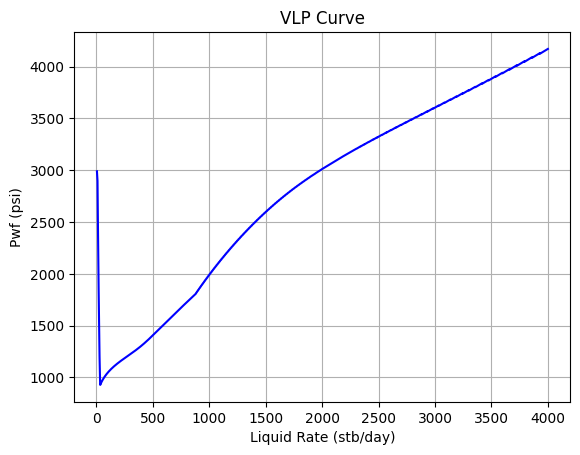

In [16]:
pvt_data = BlackOilPVT(sg_gas=0.65, sg_oil=141.5/(131.5+35), sg_water=1.07, watercut =0.33 )
Rsb = pvt_data.rsb_from_test(480, 346.6, 1800, 80)
fp = pvt_data.fluid_properties_dict(346.6, 80, Rsb, 1800)

hg = HagedornBrown(2.441/12, 2.875/12, 5.5/12, 0.0006/12, pvt_data, fp)
hg.plot_vlp_curve(346.6, 80, 130, 8245, 5, 4000, 50)

error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error


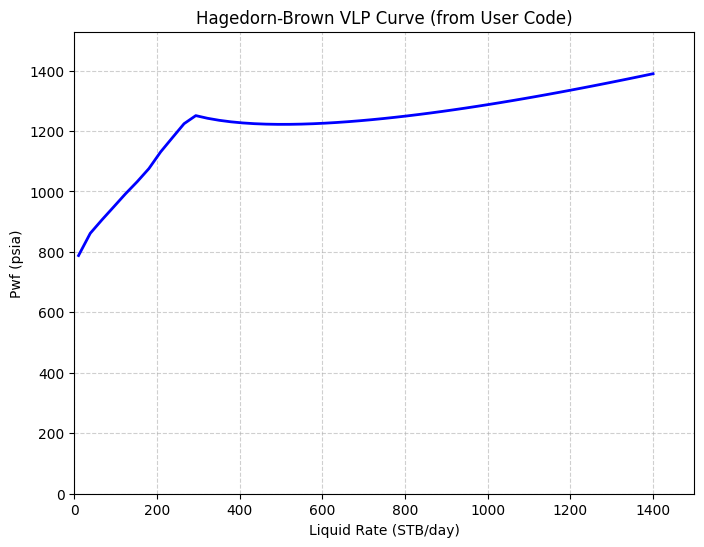

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. LIGHTWEIGHT FLUIDPROPS MOCK
# (Built so your script can run standalone without needing the missing module)
# ==============================================================================
class FluidProps:
    @staticmethod
    def Tc(sg_g): return 187 + 330*sg_g - 71.5*sg_g**2
    @staticmethod
    def Pc(sg_g): return 667 + 15*sg_g - 37.5*sg_g**2
    @staticmethod
    def zfact(Tr, Pr): return 0.85 # Simplified for standalone run
    @staticmethod
    def salinity(wtr_grav): return 100000.0 * (wtr_grav - 1.0)
    @staticmethod
    def Pbub(T, Tsep, Psep, gas_grav, oil_grav, Gor):
        a = 0.00091 * T - 0.0125 * oil_grav
        return max(18.2 * (((Gor / gas_grav)**0.83) * (10**a) - 1.4), 14.7)
    @staticmethod
    def sol_gor(T, P, Tsep, Psep, Pb, gas_grav, oil_grav):
        if P >= Pb: return Gor_global # Saturated
        a = 0.00091 * T - 0.0125 * oil_grav
        return gas_grav * (((P / 18.2) + 1.4) * (10**-a))**1.2048
    @staticmethod
    def sol_gwr(P, T, TDS): return 0.0 
    @staticmethod
    def oil_fvf(T, P, Tsep, Psep, Pb, Rso, gas_grav, oil_grav):
        sg_o = 141.5 / (131.5 + oil_grav)
        F = Rso * math.sqrt(gas_grav / sg_o) + 1.25 * T
        return 0.9759 + 0.00012 * (F**1.175)
    @staticmethod
    def wtr_fvf(P, T, TDS): return 1.02
    @staticmethod
    def gas_fvf(P, T, gas_grav):
        return 0.02827 * 0.85 * (T + 460) / max(P, 14.7)
    @staticmethod
    def oil_visc(T, P, Tsep, Psep, Pb, Rso, gas_grav, oil_grav): return 1.5
    @staticmethod
    def wtr_visc(P, T, TDS): return 0.5
    @staticmethod
    def gvisc(P, T, Z, gas_grav): return 0.015
    @staticmethod
    def oil_dens(T, P, Tsep, Psep, Pb, Bo, Rso, gas_grav, oil_grav):
        sg_o = 141.5 / (131.5 + oil_grav)
        return (350.0 * sg_o + 0.0764 * gas_grav * Rso) / (5.615 * Bo)
    @staticmethod
    def oil_tens(P, T, oil_grav): return 20.0
    @staticmethod
    def wtr_tens(P, T): return 60.0

# ==============================================================================
# 2. YOUR EXACT VLP CODE
# ==============================================================================

def Pgrad(P, T, oil_rate, wtr_rate, Gor, gas_grav, oil_grav, wtr_grav, d, angle):
    """Function to Calculate the Flowing Pressure Gradient"""
    global Gor_global
    Gor_global = Gor
    
    #Set constants
    pi = math.pi  
    Psep = 114.7                                                        
    Tsep = 50                                                           
   
    #Convert pipe angle from degrees to radians
    angle = angle * pi / 180
    
    #Calculate fluid properties
    Z = FluidProps.zfact((T + 460) / FluidProps.Tc(gas_grav), P / FluidProps.Pc(gas_grav))                
    if T==145.0:
        print ('error')
        
    Wor = wtr_rate / oil_rate                                           
    TDS = FluidProps.salinity(wtr_grav)                                           
    Pb = FluidProps.Pbub(T, Tsep, Psep, gas_grav, oil_grav, Gor)                  
    Rso = FluidProps.sol_gor(T, P, Tsep, Psep, Pb, gas_grav, oil_grav)              
    Rsw = FluidProps.sol_gwr(P, T, TDS)                                           
    Bo = FluidProps.oil_fvf(T, P, Tsep, Psep, Pb, Rso, gas_grav, oil_grav)          
    Bw = FluidProps.wtr_fvf(P, T, TDS)                                             
    Bg = FluidProps.gas_fvf(P, T, gas_grav)                                       
    muo = FluidProps.oil_visc(T, P, Tsep, Psep, Pb, Rso, gas_grav, oil_grav)        
    muw = FluidProps.wtr_visc(P, T, TDS)                                           
    mug = FluidProps.gvisc(P, (T + 460), Z, gas_grav)                                
    rhoo = FluidProps.oil_dens(T, P, Tsep, Psep, Pb, Bo, Rso, gas_grav, oil_grav)  
    rhow = 62.368 * wtr_grav / Bw                                                
    rhog = 2.699 * gas_grav * max(P, 14.7) / (T + 460) / Z                                    
    sigo = FluidProps.oil_tens(P, T, oil_grav)                                     
    sigw = FluidProps.wtr_tens(P, T)                                               
   
    #Volume fraction weighted liquid properties
    rhol = (Bw * Wor * rhow + Bo * rhoo) / (Bw * Wor + Bo)              
    mul = (Bw * Wor * rhow) / (Bw * Wor * rhow + Bo * rhoo) * muw + (Bo * rhoo) / (Bw * Wor * rhow + Bo * rhoo) * muo              
    sigl = (Bw * Wor * rhow) / (Bw * Wor * rhow + Bo * rhoo) * sigw + (Bo * rhoo) / (Bw * Wor * rhow + Bo * rhoo) * sigo            
    
    #Calculate downhole fluid flowrates in ft_/s
    qo = Bo * oil_rate / 15387                                  
    qw = Bw * Wor * oil_rate / 15387                                  
    ql = qo + qw                                                        
    if ((Gor - Rso) < 0):                                        
        qg = 0
    else:
        qg = Bg * (Gor - Rso - Rsw * Wor) * oil_rate / 86400
    
        
    #Calculate fluid superficial velocities in ft/s
    Axs = pi / 4 * (d / 12) ** 2                                         
    usl = ql / Axs                                                      
    usg = qg / Axs                                                      
    um = usl + usg                                                      
    

    #Determine flow regime
    A= 1.071 -((0.2218*um**2)/(d/12)) # Fixed d to d/12 per standard physics

    if A<0.13:
        A=0.13
    B= usg/(um)

    if B-A>=0:
        ## use Griffing Lquid holp up Correlation 
        us=0.8*0.3048 # Note: Griffith Vs is 0.8 ft/s, multiplying by 0.3048 converts to m/s, causing bug
        x=(1+um/us)**2-4*usg/us
        HL=1-0.5*(1+um/us-math.sqrt(max(x,0)))

    else:
        ## Use H&B holdup correlation
        g=32.174 
        NL=0.15726*mul*(1/(rhol*sigl**3))**0.25
        CNL=0.061*NL**3-0.0929*NL**2+0.0505*NL+0.0019

        NLv=1.938*usl*(rhol/(sigl))**0.25  
        NGv=1.938*usg*(rhol/(sigl))**0.25  
        ND=120.872*d/12*math.sqrt(rhol/(sigl))

        if NGv==0:
            H=0
        else:   
            H=NLv/(NGv**0.575)*(P/14.7)**0.1*CNL/ND
    
        H_Phi=math.sqrt((0.047+(1123.32)*H+729489.64*H**2)/(1+1097.1556*H+722153.97*H**2))

        B=NGv*(NLv**0.38)/(ND**2.14)

        if B<=0.025:
            PHI=27170*B**3-317.52*B**2+0.5472*B+0.9999
        if (B>0.025 and B<=0.055):
            PHI=-5333.33*B**2+58.524*B+0.1171
        if B>0.055:
            PHI=2.5714*B+1.5962

        HL=H_Phi*PHI

     #Liquid velocity number
    laml = usl / um                                                     
    lamg = 1 - laml                                                     
    
    yl=HL
    yg=1-HL

    #Calculate fluid mixture properties
    rhom = rhol * laml + rhog * lamg                                      
    mum=mul**yl*mug**(yg)
    rhobar = rhol * yl + rhog * yg                                       
    
    #Calculate friction factor
    Nre = 1488 * rhom * um * (d / 12) / mum                              
    fn = Fric(Nre, 0.0006)   
    
    x = laml / max(HL ** 2, 1e-6)
    if ((x > 1) and (x < 1.2)):
        s = math.log(2.2 * x - 1.2)
    else:
        s = math.log(x) / (-0.0523 + 3.182 * math.log(x) - 0.8725 * (math.log(x)) ** 2 + 0.01853 * (math.log(x)) ** 4)
    
    ftp = fn * math.exp(s)                                                  
    
    #Calculate gradients
    Pgrad_pe = rhobar * math.sin(angle) / 144                                 
    Pgrad_f = 2 * ftp * rhom * um ** 2 / 32.17 / (d / 12) / 144           
    Ek = um * usg * rhobar / 32.17 / P / 144                              
    return (Pgrad_pe + Pgrad_f) / (1 - Ek)                               


def Fric(Nre, eps):
    try:
        Temp = -4 * math.log10((eps / 3.7065) - (5.0452 / max(Nre,1)) * math.log10((eps ** 1.1098 / 2.8257) + (7.149 / max(Nre,1)) ** 0.8981) ) 
    except Exception as inst:
         return 0.02
    return (1 / Temp) ** 2


def Pwf_q(FWHP, FWHT,Oil_Rate,Water_Rate,GOR,GasGrav,API, WaterGrav, ID, Angle, Depth, FBHT):
    DPs = []  
    PressList=[]
    DepthList=[]
    
    PressList.append(FWHP)
    DepthList.append(0)
    DPs.append(0)
    nSteps=60
    i=1
    Tgrad= (FBHT-FWHT)/ Depth

    while (i<= nSteps):
        DeltaD= Depth/nSteps*i
        DepthList.append(DeltaD) 
        T=FWHT+Tgrad*DeltaD
        
        p = PressList[i-1] + DPs[i-1] * (DepthList[i] - DepthList[i-1])     
        dp = Pgrad(max(p,14.7),T,Oil_Rate,Water_Rate,GOR,GasGrav,API, WaterGrav, ID, Angle)
        DPs.append(dp)
        PressList.append(p)
        i=i+1

    return PressList[-1]

# ==============================================================================
# 3. EXECUTE AND PLOT (Using inputs from your images)
# ==============================================================================

rates = np.linspace(10, 1400, 50)
pwfs = []

for q in rates:
    oil_rate = q * (1 - 0.33)  # 33% water cut
    wtr_rate = q * 0.33
    
    # Inputs: FWHP, FWHT, Qo, Qw, GOR, SGg, API, SGw, ID, Angle (90=Vert), Depth, FBHT
    pwf = Pwf_q(150.0, 100.0, oil_rate, wtr_rate, 500.0, 0.650, 35.0, 1.070, 2.44, 90.0, 6000.0, 200.0)
    pwfs.append(pwf)

plt.figure(figsize=(8, 6))
plt.plot(rates, pwfs, color='blue', linewidth=2)
plt.title("Hagedorn-Brown VLP Curve (from User Code)")
plt.xlabel("Liquid Rate (STB/day)")
plt.ylabel("Pwf (psia)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(0, 1500)
plt.ylim(0, max(pwfs)*1.1)
plt.show()

<a name = '3'></a>
## Beggs and Brill

In [ ]:
class Beggs_Brill:
    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model,
                 fluid_properties, watercut=0.0, theta=0.0):
        self.tid      = tubing_id #ft
        self.tod      = tubing_od #ft
        self.cid      = casing_id #ft
        self.roughness = roughness #ft
        self.pvt_model = pvt_model 
        self.wc       = watercut #ratio
        self.wor      = watercut / (1.0 - watercut + 1e-9)
        self.theta    = np.radians(theta) #degrees
        self.Ap       = (np.pi / 4.0) * self.tid**2
        self.fp       = fluid_properties #{"M","Pb","Rsb","gor","glr","rho_l","rho_g","mu_l","mu_g","sigma_l","Bo","Bg","Bw","Pr","Tr","Z",}
        self._superficial_velocities()

    def _update_fluid_properties(self, P, T, Ql):
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(
            P, T, self.fp["Rsb"], self.fp["Pb"]
        )
    
    def _superficial_velocities(self):
        fo = (1 - self.wc)
        fw = self.wc

        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"]  = q_liquid_insitu / (86400.0 * self.Ap)

        free_gas_scf   = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu   = (free_gas_scf
                          * (14.7 / self.fp["Pr"])
                          * ((self.fp["Tr"] + 460.0) / 520.0)
                          * self.fp["Z"])
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)
        self.fp["Vm"]  = self.fp["Vsl"] + self.fp["Vsg"]

        self.fp["Cl"] = self.fp["Vsl"] / self.fp["Vm"]

    def _dimensionless_numbers(self):
        self._superficial_velocities()
        Gm = self.fp["rho_l"] * self.fp["Vsl"] + self.fp["rho_g"] * self.fp["Vsg"]

        L1 = 316 * self.fp["Cl"] ** 0.302
        L2 = 0.0009252 * self.fp["Cl"] ** (-2.4684)
        L3 = 0.1 * self.fp["Cl"] ** (-1.4516)
        L4 = 0.5 * self.fp["Cl"] ** (-6.738)

        Nfr = self.fp["Vm"]**2/(32.17 * self.tid)

        return Gm, L1, L2, L3, L4, Nfr
    
    def find_flow_pattern(self, Gm, L1, L2, L3, L4, Nfr):
        if (self.fp["Cl"]<0.01 and Nfr < L1) or (self.fp["Cl"] >= 0.01 and Nfr < L2):
            return "segregated"
        elif (self.fp["Cl"]>=0.01 and L2 <= Nfr <= L3):
            return "transitional"
        elif (0.01 <= self.fp["Cl"] < 0.4 and L3 < Nfr <= L1) or (self.fp["Cl"] >= 0.4 and L3 < Nfr <= L4):
            return "intermittent"
        elif (self.fp["Cl"]<0.4 and Nfr >= L1) or (self.fp["Cl"] >= 0.4 and Nfr > L4):
            return "distributed"
        
    def calculate_holdup(self, Gm, L1, L2, L3, L4, Nfr):
        Nlv = 1.938 * self.fp["Vsl"] * (self.fp["rho_l"]/self.fp["sigma_l"])**0.25
        flow_pattern = self.find_flow_pattern(Gm, L1, L2, L3, L4, Nfr)
        
        if flow_pattern == "segregated":
            Hl0 = 0.98 * (self.fp["Cl"]**0.4846/Nfr**0.0868)
            C = (1 - self.fp["Cl"]) * np.log(0.011 * Nlv ** 3.359 * self.fp["Cl"] ** (-3.768) * Nfr**(-1.614))
        elif flow_pattern == "intermittent":
            Hl0 = 0.845 * (self.fp["Cl"]**0.5351/Nfr**0.0173)
            C = (1 - self.fp["Cl"]) * np.log(2.96 * Nlv ** (-0.4473) * self.fp["Cl"] ** 0.305 * Nfr**(0.0978))
        elif flow_pattern == "distributed":
            Hl0 = 1.065 * (self.fp["Cl"]**0.5824/Nfr**0.0609)
            C = 0
        elif flow_pattern == "transitional":
            Hl0 = 0.98 * (self.fp["Cl"]**0.4846/Nfr**0.0868)
            C = (1 - self.fp["Cl"]) * np.log(0.011 * Nlv ** 3.359 * self.fp["Cl"] ** (-3.768) * Nfr**(-1.614))
            psi = 1 + C * (np.sin(1.8 * self.theta) - 0.333 * np.sin(1.8* self.theta)**3)
            Hl_segregated = Hl0 * psi
            Hl0 = 0.845 * (self.fp["Cl"]**0.5351/Nfr**0.0173)
            C = (1 - self.fp["Cl"]) * np.log(2.96 * Nlv ** (-0.4473) * self.fp["Cl"] ** 0.305 * Nfr**(0.0978))
            psi = 1 + C * (np.sin(1.8 * self.theta) - 0.333 * np.sin(1.8* self.theta)**3)
            Hl_intermittent = Hl0*psi

            A = (L3 - Nfr)/(L3 - L2)
            Hl = A * Hl_segregated + (1-A) * Hl_intermittent
            return max(Hl, self.fp["Cl"])
        
        psi = 1 + C * (np.sin(1.8 * self.theta) - 0.333 * np.sin(1.8* self.theta)**3)
        Hl = Hl0 * psi
        return max(Hl, self.fp["Cl"])
    
    def frictional_factor(self, Gm, L1, L2, L3, L4, Nfr):
        rho_ns = self.fp["rho_l"] * self.fp["Cl"] + self.fp["rho_g"] * (1 - self.fp["Cl"])
        mu_ns = self.fp["mu_l"] * self.fp["Cl"] + self.fp["mu_g"] * (1 - self.fp["Cl"])
        Re = 1488 * rho_ns * self.fp["Vm"] *self.tid / mu_ns

        if Re < 2000:
            f = 64.0 / max(Re, 1.0)
        else:
            f = (1.14 - 2.0 * np.log10(self.roughness + 21.25 / (Re ** 0.9))) ** -2
        
        H_L = max(self.calculate_holdup(Gm, L1, L2, L3, L4, Nfr), 1e-6) # Actual slip holdup calculated previously
        y = max(self.fp["Cl"] / (H_L ** 2), 1e-6)
        ln_y = np.log(y)
        
        if 1.0 <= y <= 1.2:
            S = np.log(2.2 * y - 1.2)
        else:
            denominator = -0.0523 + 3.182 * ln_y - 0.8725 * (ln_y ** 2) + 0.01853 * (ln_y ** 4)
            S = ln_y / denominator
            
        f_prime = f * np.exp(S)
        if self.fp["Cl"] <0.001:
            f_prime = f
        
        return f_prime, H_L
    
    def calculate_gradient(self, P):
        Gm, L1, L2, L3, L4, Nfr = self._dimensionless_numbers()
        f_prime, Hl = self.frictional_factor(Gm, L1, L2, L3, L4, Nfr)
        rho_m = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1-Hl)
        dp_dz = 1/144 * ( np.sin(self.theta)*rho_m + f_prime * Gm * self.fp["Vm"]/(2*32.17*self.tid) )/( 1 - rho_m * self.fp["Vm"] * self.fp["Vsg"] / (32.17 * P/144))
        return dp_dz
    
    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                                    total_depth, step_size, Ql):
        """
        Calculates the wellbore pressure profile via Euler integration.

        Returns:
            tuple: (depths [ft], pressures [psia])
        """
        depths        = [0.0]
        pressures     = [Pth]
        current_P     = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        while current_depth < total_depth:
            next_depth   = min(current_depth + step_size, total_depth)
            actual_step  = next_depth - current_depth
            current_temp = surface_temp + temp_gradient * current_depth

            self.update_fluid_properties(current_P, current_temp, Ql)
            dp_dz     = self.calculate_gradient(current_P)
            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)

        return depths, pressures

    def plot_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                               total_depth, step_size, Ql):
        depths, pressures = self.calculate_pressure_traverse(
            Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql
        )
        plt.plot(pressures, depths, color='blue', linewidth=2)
        plt.gca().invert_yaxis()
        plt.xlabel('Pressure (psia)')
        plt.ylabel('Depth (ft)')
        plt.title('Pressure Traverse Curve')
        plt.grid(True)
        plt.show()
        return pressures[-1]

    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp,
                       depth, Qmin, Qmax, step_size):
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            _, pressures = self.calculate_pressure_traverse(
                Pth, surface_temp, bottomhole_temp, depth, step_size, q
            )
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
        """Simplified single-gradient VLP (stale PVT — approximate only)."""
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, int((Qmax - Qmin) / step_size))

        for q in rates:
            self.Ql = q
            Pwf = Pth + self.calculate_gradient() * depth
            Pwf_points.append(Pwf)

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class Beggs_Brill:
    """
    Calculates multiphase flow pressure gradients and VLP curves for wellbores
    at any inclination angle using the Beggs and Brill (1973) correlation.
    """
    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model,
                 fluid_properties, watercut=0.0, theta=0.0):
        """
        Initializes the wellbore geometry and base PVT parameters.

        Args:
            tubing_id (float): Tubing inner diameter in feet (ft).
            tubing_od (float): Tubing outer diameter in feet (ft).
            casing_id (float): Casing inner diameter in feet (ft).
            roughness (float): Absolute pipe roughness in feet (ft).
            pvt_model (object): Instance of the BlackOilPVT class.
            fluid_properties (dict): Initial dictionary of PVT properties.
            watercut (float): Watercut as a decimal fraction (0.0 to 1.0).
            theta (float): Well deviation from vertical in degrees (0 = vertical).
        """
        self.tid = tubing_id
        self.tod = tubing_od
        self.cid = casing_id
        self.roughness = roughness
        self.pvt_model = pvt_model 
        self.wc = watercut
        
        # Convert deviation from vertical (UI) to radians
        self.theta = np.radians(theta) 
        
        self.Ap = (np.pi / 4.0) * self.tid**2
        self.fp = fluid_properties 
        self.Ql = 0.0

    def _update_fluid_properties(self, P, T, Ql):
        """
        Updates the in-situ fluid properties and superficial velocities 
        based on local pressure and temperature.
        """
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(
            P, T, self.fp["Rsb"], self.wc
        )
        self._superficial_velocities()
    
    def _superficial_velocities(self):
        """Calculates in-situ superficial velocities and no-slip liquid holdup (Cl)."""
        fo = (1.0 - self.wc)
        fw = self.wc

        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"] = q_liquid_insitu / (86400.0 * self.Ap)

        free_gas_scf = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu = (free_gas_scf * (14.7 / self.fp["Pr"]) 
                        * ((self.fp["Tr"] + 460.0) / 520.0) * self.fp["Z"])
        
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)
        self.fp["Vm"]  = self.fp["Vsl"] + self.fp["Vsg"]
        
        # No-slip liquid holdup
        self.fp["Cl"] = self.fp["Vsl"] / max(self.fp["Vm"], 1e-6)

    def _dimensionless_numbers(self):
        """Calculates Beggs and Brill specific dimensionless groups."""
        self._superficial_velocities()
        Gm = self.fp["rho_l"] * self.fp["Vsl"] + self.fp["rho_g"] * self.fp["Vsg"]
        
        Cl = max(self.fp["Cl"], 1e-6) # Prevent divide-by-zero
        L1 = 316.0 * Cl ** 0.302
        L2 = 0.0009252 * Cl ** (-2.4684)
        L3 = 0.1 * Cl ** (-1.4516)
        L4 = 0.5 * Cl ** (-6.738)

        # Froude Number
        Nfr = (self.fp["Vm"]**2) / (32.174 * self.tid)

        return Gm, L1, L2, L3, L4, Nfr
    
    def find_flow_pattern(self, L1, L2, L3, L4, Nfr):
        """Determines the Beggs and Brill flow pattern (Segregated, Intermittent, Distributed, Transitional)."""
        Cl = self.fp["Cl"]
        if (Cl < 0.01 and Nfr < L1) or (Cl >= 0.01 and Nfr < L2):
            return "segregated"
        elif (Cl >= 0.01 and L2 <= Nfr <= L3):
            return "transitional"
        elif (0.01 <= Cl < 0.4 and L3 < Nfr <= L1) or (Cl >= 0.4 and L3 < Nfr <= L4):
            return "intermittent"
        elif (Cl < 0.4 and Nfr >= L1) or (Cl >= 0.4 and Nfr > L4):
            return "distributed"
        return "distributed" # Fallback
        
    def calculate_holdup(self, L1, L2, L3, L4, Nfr):
        """
        Calculates the actual liquid holdup fraction (Hl), including angle 
        correction (psi) and transitional blending.
        """
        Cl = max(self.fp["Cl"], 1e-6)
        Nlv = 1.938 * self.fp["Vsl"] * (self.fp["rho_l"] / max(self.fp["sigma_l"], 1e-6))**0.25
        flow_pattern = self.find_flow_pattern(L1, L2, L3, L4, Nfr)
        
        # B&B uses angle from HORIZONTAL (0 = horizontal, 90 = vertical)
        theta_h = (np.pi / 2.0) - self.theta 
        sin_term = np.sin(1.8 * theta_h)

        def get_C_and_Hl0(pattern):
            if pattern == "segregated":
                hl0 = 0.98 * (Cl**0.4846 / Nfr**0.0868)
                c = (1 - Cl) * np.log(0.011 * Nlv**3.539 * Cl**(-3.768) * Nfr**(-1.614))
            elif pattern == "intermittent":
                hl0 = 0.845 * (Cl**0.5351 / Nfr**0.0173)
                c = (1 - Cl) * np.log(2.96 * Nlv**(-0.4473) * Cl**0.305 * Nfr**(0.0978))
            else: # distributed
                hl0 = 1.065 * (Cl**0.5824 / Nfr**0.0609)
                c = 0.0
                
            # PDF Constraints: Hl(0) >= Cl and C >= 0
            return max(hl0, Cl), max(c, 0.0)

        # Apply interpolation if falling between segregated and intermittent
        if flow_pattern == "transitional":
            hl0_seg, c_seg = get_C_and_Hl0("segregated")
            psi_seg = 1.0 + c_seg * (sin_term - 0.333 * sin_term**3)
            hl_seg = hl0_seg * psi_seg

            hl0_int, c_int = get_C_and_Hl0("intermittent")
            psi_int = 1.0 + c_int * (sin_term - 0.333 * sin_term**3)
            hl_int = hl0_int * psi_int

            A = (L3 - Nfr) / (L3 - L2)
            Hl = A * hl_seg + (1.0 - A) * hl_int
        else:
            hl0, c = get_C_and_Hl0(flow_pattern)
            psi = 1.0 + c * (sin_term - 0.333 * sin_term**3)
            Hl = hl0 * psi

        # PDF Final Modifications: Hl must be between Cl and 1.0
        return max(Cl, min(Hl, 1.0))
    
    def frictional_factor(self, Gm, L1, L2, L3, L4, Nfr):
        """Calculates the corrected two-phase friction factor and returns the actual Holdup."""
        Cl = self.fp["Cl"]
        rho_ns = self.fp["rho_l"] * Cl + self.fp["rho_g"] * (1 - Cl)
        mu_ns = self.fp["mu_l"] * Cl + self.fp["mu_g"] * (1 - Cl)
        
        Re = 1488.0 * rho_ns * self.fp["Vm"] * self.tid / max(mu_ns, 1e-6)

        if Re < 2000:
            f = 64.0 / max(Re, 1.0)
        else:
            f = (1.14 - 2.0 * np.log10(self.roughness + 21.25 / (Re ** 0.9))) ** -2
        
        H_L = max(self.calculate_holdup(L1, L2, L3, L4, Nfr), 1e-6) 
        y = max(Cl / (H_L ** 2), 1e-6)
        ln_y = np.log(y)
        
        if 1.0 <= y <= 1.2:
            S = np.log(2.2 * y - 1.2)
        else:
            denominator = -0.0523 + 3.182 * ln_y - 0.8725 * (ln_y ** 2) + 0.01853 * (ln_y ** 4)
            S = ln_y / denominator
            
        f_prime = f * np.exp(S)
        
        # PDF Modification: Force approach gas at low liquid content
        if Cl < 0.001:
            f_prime = f
            
        return f_prime, H_L
    
    def calculate_gradient(self, P):
        """
        Calculates the total multiphase pressure gradient (psi/ft).
        
        Args:
            P (float): Local node pressure in psia.
            
        Returns:
            float: Pressure gradient (dp/dz) in psi/ft.
        """
        Gm, L1, L2, L3, L4, Nfr = self._dimensionless_numbers()
        f_prime, Hl = self.frictional_factor(Gm, L1, L2, L3, L4, Nfr)
        
        rho_m = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        gc = 32.174
        
        # Angle from horizontal for elevation calculation
        theta_h = (np.pi / 2.0) - self.theta 
        
        hydrostatic = np.sin(theta_h) * rho_m
        friction = (f_prime * Gm * self.fp["Vm"]) / (2.0 * gc * self.tid)
        
        # Kinetic energy term (Denominator unit correction applied: P * 144)
        kinetic_term = 1.0 - (rho_m * self.fp["Vm"] * self.fp["Vsg"]) / (gc * P * 144.0)
        
        # Calculate total dp/dz (psf/ft) and divide by 144 for psi/ft
        dp_dz = (hydrostatic + friction) / kinetic_term / 144.0
        return dp_dz
    
    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                                    total_depth, step_size, Ql):
        """
        Calculates the wellbore pressure profile via Euler integration.

        Args:
            Pth (float): Wellhead tubing pressure in psia.
            surface_temp (float): Surface temperature in Fahrenheit (°F).
            bottomhole_temp (float): Bottomhole temperature in Fahrenheit (°F).
            total_depth (float): Total vertical depth of the well in feet (ft).
            step_size (float): Depth integration step size in feet (ft).
            Ql (float): Surface liquid flow rate in STB/day.

        Returns:
            tuple: (depths [ft], pressures [psia])
        """
        depths = [0.0]
        pressures = [Pth]
        current_P = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        while current_depth < total_depth:
            next_depth = min(current_depth + step_size, total_depth)
            actual_step = next_depth - current_depth
            current_temp = surface_temp + temp_gradient * current_depth

            # Fixed: Call internal method properly
            self._update_fluid_properties(current_P, current_temp, Ql)
            dp_dz = self.calculate_gradient(current_P)
            
            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)

        return depths, pressures
    
    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp,
                       depth, Qmin, Qmax, step_size):
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            _, pressures = self.calculate_pressure_traverse(
                Pth, surface_temp, bottomhole_temp, depth, step_size, q
            )
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
        """Simplified single-gradient VLP (stale PVT — approximate only)."""
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, int((Qmax - Qmin) / step_size))

        for q in rates:
            self.Ql = q
            Pwf = Pth + self.calculate_gradient() * depth
            Pwf_points.append(Pwf)

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')

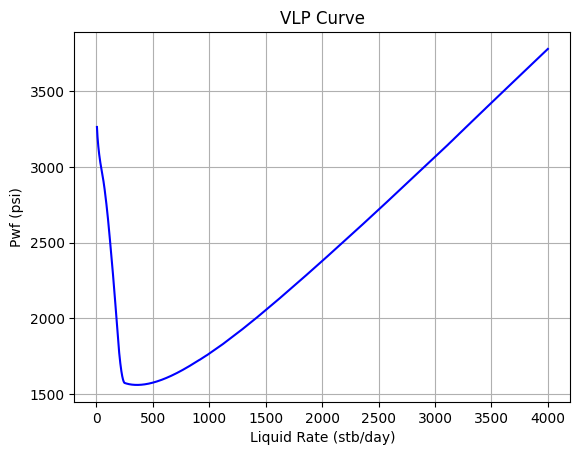

In [13]:
pvt_data = BlackOilPVT(sg_gas=0.65, sg_oil=141.5/(131.5+35), sg_water=1.07, watercut =0.33 )
Rsb = pvt_data.rsb_from_test(480, 346.6, 1800, 80)
fp = pvt_data.fluid_properties_dict(346.6, 80, Rsb, 1800)

bb = Beggs_Brill(2.441/12, 2.875/12, 5.5/12, 0.0006/12, pvt_data, fp)
bb.plot_vlp_curve(346.6, 80, 130, 8245, 5, 4000, 50)

<a name = '4'></a>
## Duns and Ros

In [ ]:
import numpy as np
from scipy.interpolate import PchipInterpolator


class ChartFunction:
    """
    Digitized chart interpolation.

    Supports:
        - linear interpolation
        - log-x interpolation
        - log-log interpolation
    """

    def __init__(
        self,
        points: list[tuple[float, float]],
        name: str,
        logx: bool = True,
        logy: bool = False,
    ):
        pts = sorted(points)

        self.name = name
        self.logx = logx
        self.logy = logy

        self.x = np.array([p[0] for p in pts], dtype=float)
        self.y = np.array([p[1] for p in pts], dtype=float)

        x_interp = np.log10(self.x) if logx else self.x
        y_interp = np.log10(self.y) if logy else self.y

        self._interp = PchipInterpolator(
            x_interp,
            y_interp,
            extrapolate=True,
        )

    def __call__(self, x):

        x = np.clip(x, self.x.min(), self.x.max())

        if self.logx:
            x = np.log10(x)

        y = self._interp(x)

        if self.logy:
            y = 10 ** y

        return float(y)
CHART_DATA = {
    # L1, L2 vs Nd (flow regime boundary chart, Duns & Ros Fig.)
    "L1": ChartFunction(
    [
        (18.633328021022624, 1.9673441797585194),
        (21.081474510081954, 1.9668080742156544),
        (23.470311678288823, 1.966341895482728),
        (26.129838783932364, 1.9658757167498018),
        (28.928803671488236, 1.9454337793109877),
        (31.01098401000279, 1.920131928581418),
        (33.05444524262925, 1.8648547853246935),
        (34.85264905282858, 1.7996247261199945),
        (36.16365701336464, 1.7394643606358677),
        (38.33415078713324, 1.6692112255838887),
        (41.06022129878563, 1.5689128711948161),
        (45.38779351524844, 1.4034776933476294),
        (50.44959401045713, 1.253018507295697),
        (54.31928958587173, 1.1376975432380774),
        (56.0728940865842, 1.0975595543331311),
        (58.194609196629045, 1.0573982564915387),
        (62.04264687193397, 1.0221201808773483),
        (66.15223119848132, 0.9968416390844246),
        (70.17907440825354, 1.0015850076919488),
        (75.64325706044883, 0.986259381847),
        (80.25214860704445, 0.9960025173651574),
        (85.58626689674351, 0.9907230432147682),
        (100.52735960982052, 0.9800242412941118),
        (130.7950478568692, 0.9988811710409768),
        (170.12121383613172, 0.9877394993240407),
        (214.25959640296347, 0.9767376812269819),
        (259.9276344803129, 0.9758985595077148),
    ],
    "L1 vs Nd",
    logx=True,
    logy=False,
    ),
    "L2": ChartFunction(
    [
        (14.712432733805487, 0.45837023914968933),
        (16.036834321876487, 0.4879958976271501),
        (18.053502301358748, 0.5224814693953661),
        (20.656983216109897, 0.5718964150855439),
        (22.517717060630957, 0.6065218404736372),
        (24.676831962353383, 0.636124190014451),
        (28.699924316922647, 0.705468276537224),
        (31.972627801598087, 0.7649993007319),
        (36.39341385478015, 0.8294368560906249),
        (41.42767582563093, 0.898874178359983),
        (46.65732801549707, 0.973357885413267),
        (50.311691631081686, 0.9980303948533864),
        (53.38574342176924, 1.022772831103445),
        (56.641539909976416, 1.037515733532236),
        (60.74444891702114, 1.0522120180877346),
        (65.14106159771141, 1.0619085357325995),
        (68.74751498232226, 1.0816745140086705),
        (72.9284250387007, 1.0814181157055611),
        (77.7799319099715, 1.0811384084658053),
        (81.63359275458912, 1.0859283949466223),
        (90.89849875583491, 1.1004615169455967),
        (100.10739925184689, 1.0900424222646958),
        (126.76582612488139, 1.0840170621416247),
        (150.53497201988117, 1.09327070999021),
        (198.9637464087474, 1.0770593445527012),
        (240.10535497735594, 1.0862430655913473),
        (292.84978644218404, 1.0853806349354338),
    ],
    "L2 vs Nd",
    logx=True,
    logy=False,
    ),
 
    # Bubble flow slip-velocity factors F1-F4 (functions of NLv mostly)
    "F1": ChartFunction(
    [
        (0.0047097734208786275, 1.1884377832092687),
        (0.005876826558681099, 1.1948064745418547),
        (0.00716416256290527, 1.201310241689731),
        (0.008632326130161976, 1.2005029048843316),
        (0.010280875429245573, 1.2071391163674168),
        (0.011962227378650511, 1.1990913708102204),
        (0.013597958411538933, 1.22082952939805),
        (0.0160072163705201, 1.2276296839020686),
        (0.019064177487373227, 1.2496751612401715),
        (0.021925013954577844, 1.2722768877953283),
        (0.025215157445256677, 1.3032686916358431),
        (0.029682726540805376, 1.3349032527324867),
        (0.0341370192366346, 1.375846363347798),
        (0.03835545170522658, 1.4094794888767415),
        (0.041614832900421804, 1.4619683560857015),
        (0.0462156972405333, 1.5162844782051967),
        (0.0495621813410424, 1.5825082169568252),
        (0.05253529373289193, 1.6215339003682143),
        (0.0556867557666538, 1.7133465473816603),
        (0.06184338769249529, 1.798968584678263),
        (0.0711238205295976, 1.8886313813676314),
        (0.08470661648913988, 1.9825131677969534),
        (0.09971475843062777, 2.018199457409207),
        (0.13035956500855575, 2.0537513391547657),
        (0.1645681974742974, 2.0773924698341797),
        (0.205347193422057, 2.063022767715851),
        (0.2562309759326464, 2.0237359185694817),
        (0.3234704706443913, 1.9608743347023152),
        (0.39432762101387847, 1.8427282999136727),
        (0.4696339189259032, 1.7425175828221893),
        (0.546438653165416, 1.6580489671646061),
        (0.5860063406375826, 1.5684744399947577),
        (0.6358041649890819, 1.5020173187960186),
        (0.706097579767229, 1.4119927469751794),
        (0.7841625135653214, 1.3273638676208042),
        (0.8708581721577248, 1.255496023477772),
        (0.9899404878797302, 1.172920419752072),
        (1.1518370482015015, 1.0756767552025779),
        (1.3559171381563269, 0.9986479657940792),
        (1.6148619711038166, 0.9385565840701039),
        (1.8356803652333444, 0.8931350634623554),
    ],
    "F1 vs NL",
    logx=True,
    logy=True,
    ),
    "F2": ChartFunction(
    [
        (0.0023961350191944964, 0.24569931139646597),
        (0.002887178892992733, 0.2425360644020282),
        (0.0039087474120943376, 0.23784740124687861),
        (0.0046552162907420045, 0.24211860742808483),
        (0.005674955001538332, 0.238991418153314),
        (0.006680431712859501, 0.2373881374894177),
        (0.007772960939634417, 0.2372585063543518),
        (0.009475650712270009, 0.238549990885161),
        (0.011285253026238723, 0.24433010716695236),
        (0.012978757160916374, 0.24722572610193402),
        (0.015101325302466297, 0.2501451511793063),
        (0.017367482452809117, 0.2578174080066484),
        (0.01974233532192502, 0.26902106241493245),
        (0.022441928760969402, 0.28593268496916946),
        (0.026418142972389008, 0.32312073084127485),
        (0.030382540957106366, 0.36969024153915314),
        (0.0341370192366346, 0.4152830195386351),
        (0.03971984574157566, 0.4780429467551138),
        (0.046757325309184146, 0.5435453181912899),
        (0.05377389140242689, 0.614289758694431),
        (0.06112700551252204, 0.6774195726140168),
        (0.0711238205295976, 0.756208160125373),
        (0.08874786960881664, 0.8543801321026386),
        (0.11334988838084534, 0.9475910561080507),
        (0.12298216953621659, 0.9889355513084734),
        (0.1464685585270488, 1.0317370920262887),
        (0.187071473755072, 1.0564699259522583),
        (0.22021640797257086, 1.0493825676807544),
        (0.2562309759326464, 1.036002910485813),
        (0.2878943458607774, 1.0042443003367811),
        (0.31972344950658704, 0.9916068008858617),
        (0.45350178884617676, 0.9428648986372893),
        (0.6432555159906893, 0.8801485257431317),
        (0.8708581721577248, 0.8318999606670943),
        (1.086651517521671, 0.7913740415023925),
        (1.9232585180412767, 0.6899148958956611),
    ],
    "F2 vs NL",
    logx=True,
    logy=True,
    ),
    "F3": ChartFunction(
    [
        (0.002157595024730548, 0.8500974373239191),
        (0.0025696394391900197, 0.8495618273218977),
        (0.0032063804249099306, 0.8436852534115794),
        (0.0037744802325752045, 0.8483846728946501),
        (0.004443234781319241, 0.853110268660153),
        (0.005291776816682573, 0.884582614507784),
        (0.0059457004350657395, 0.9230616181163386),
        (0.006837932824266713, 0.9690681392428466),
        (0.008143799770748056, 1.055431716261751),
        (0.009365886555305094, 1.1638482519535336),
        (0.010771363913185596, 1.291309662988984),
        (0.012532931188056616, 1.4238963309801262),
        (0.014582588187581536, 1.5895053349355652),
        (0.017776946677014453, 1.7850091316332415),
        (0.020444616832878213, 2.0049804086980276),
        (0.026418142972389008, 2.1964739098523873),
        (0.033741582421624915, 2.4211853467951143),
        (0.04113277449733655, 2.588593722237542),
        (0.05073068346493268, 2.7336685330211092),
        (0.06555321920772467, 2.886388746745508),
        (0.08084938724349282, 3.0109332930006794),
        (0.10818834938218304, 3.1592757583036177),
        (0.12884950430771666, 3.2358256721454928),
        (0.18490447296194223, 3.3943922785435547),
        (0.2716016369711303, 3.4954168586989294),
        (0.39432762101387847, 3.599599393935142),
        (0.5860063406375826, 3.6838763407936925),
        (0.9448622217470078, 3.7690177486136833),
        (1.3878849009319898, 3.8103217953732416),
        (1.8356803652333444, 3.853535438648476),
    ],
    "F3 vs NL",
    logx=True,
    logy=True,
    ),
    "F4": ChartFunction(
    [
        (0.0022268088724126454, -17.112700900473712),
        (0.0025422502164772543, -12.736612900427431),
        (0.0029675749575328756, -9.463475007084682),
        (0.0035543707501802446, -3.7209167828164027),
        (0.004253738397308992, 1.1972482635374604),
        (0.005336438759844322, 6.657490356198906),
        (0.006542311977171822, 12.396289377649495),
        (0.008305944165907105, 18.129449594873606),
        (0.010671458248729926, 24.13552793666031),
        (0.014711261806232138, 30.679924121936963),
        (0.020045492618077247, 37.22619990862245),
        (0.024822747189981904, 41.314332972835416),
        (0.0310734391599242, 44.57619325772515),
        (0.037107021896188815, 47.29597649630729),
        (0.044794969596732785, 49.18948695556621),
        (0.05610531994860591, 53.00094269239888),
        (0.07521618470276938, 54.87753673897829),
        (0.09402914412307273, 56.76540839401072),
        (0.11207419966712848, 57.56160755079261),
        (0.15000541885596605, 57.78941524154323),
        (0.22822386317236415, 57.996547316796686),
        (0.343113773409134, 57.93076126748751),
        (0.5865238997951222, 58.119097328652636),
        (1.1524181910739129, 57.73528272096882),
        (1.9245933247620426, 57.92737798495161),
        ],
    "F4 vs NL",
    logx=True,
    logy=False,
    ),
 
    # Slug flow slip-velocity factors F5-F7
    "F5": ChartFunction(
    [
        (0.0019632644688572223, 0.21785354835439572),
        (0.0025093579826765845, 0.2150478893587228),
        (0.003950786491029975, 0.21089307736271523),
        (0.0049294083612042225, 0.20553867555252173),
        (0.0060779091213905324, 0.19777954314172455),
        (0.009232837382508524, 0.18786765860887447),
        (0.012556267289580522, 0.18076196820262094),
        (0.015672587454780014, 0.17393652128682818),
        (0.020540895633127745, 0.16843481563900084),
        (0.0272904055169515, 0.15597412762428822),
        (0.033681519436155515, 0.14536893318135607),
        (0.04106318352028642, 0.1354860989913991),
        (0.05395469248542661, 0.12074718149402199),
        (0.06269450292781399, 0.10900533355346764),
        (0.07022107438159088, 0.09840808612911657),
        (0.07770861837724322, 0.08827630867853933),
        (0.08289124634704675, 0.07918990737863194),
        (0.08966624924110221, 0.06706989223521147),
        (0.09688188935589001, 0.059023901785505185),
        (0.10328296883450494, 0.053972787974449155),
        (0.1184365991719433, 0.050305847855399925),
        (0.137407525928562, 0.04779464753851634),
        (0.1652890099168218, 0.046285933675209584),
        (0.20100505879067126, 0.04687388883294972),
        (0.23824388870938212, 0.049324611144728525),
        (0.2855292195226913, 0.05393054270100632),
        (0.32997878903301314, 0.05821979761372023),
        (0.441057063746522, 0.06613745375454232),
        (0.603915417703538, 0.07609630462318888),
        (0.7505821447164076, 0.08426940107310579),
        (0.9685463331413948, 0.09096387106047263),
        (1.1470896407164806, 0.09819664286992245),
        (1.4094074068464237, 0.10600151091281479),
        (1.8882469082245943, 0.11153309882338129),
    ],
    "F5 vs NL",
    logx=True,
    logy=True,
    ),
    "F6": ChartFunction(
    [
        (0.0023045680598371802, 0.8960501146673954),
        (0.0024992695145586094, 0.7947692297049089),
        (0.0029103762958418472, 0.6428063937017678),
        (0.003390856974545664, 0.5020840755870868),
        (0.004250885393400691, 0.3556418779855899),
        (0.005393335942398626, 0.20356281801609866),
        (0.00763254901445598, 0.02885329145580906),
        (0.010204379904056348, -0.05022881593375228),
        (0.011938262991657695, -0.10102699094075662),
        (0.015059215916485206, -0.1125829738807389),
        (0.019015691693788365, -0.10165792104380156),
        (0.022089663809180482, -0.04003431374244615),
        (0.024490303307265735, 0.07223803775203486),
        (0.027846858709661252, 0.20133795923167686),
        (0.0316634518677349, 0.3304378807113184),
        (0.034695032746403974, 0.4539673535180233),
        (0.03707758951008682, 0.5662895152837977),
        (0.04161374855515424, 0.6785452633545148),
        (0.04559800917640705, 0.8020747361612193),
        (0.05190108991824019, 0.95365569341778),
        (0.05760100814781605, 1.0884090806891806),
        (0.06313224959236584, 1.2175588124401155),
        (0.06836979743348712, 1.3523454065590446),
        (0.0748964440897356, 1.4702546204215197),
        (0.08743167231137836, 1.6386631476632414),
        (0.09492993554579546, 1.8296523312244681),
        (0.10695733942836569, 2.026211963458632),
        (0.11991883175623952, 2.1159866757524295),
        (0.14264893520263436, 2.160716299373567),
        (0.16489781668162143, 2.1155549867345567),
        (0.18600332101946462, 2.0704268809430744),
        (0.2283599641551177, 2.0027015154083236),
        (0.28028967283159484, 1.9293558909293425),
        (0.34027858972778907, 1.8841281645952743),
        (0.43874789748909243, 1.8163363853654657),
        (0.5734247682008801, 1.7766292974330418),
        (0.6966912995641216, 1.7482623479316632),
        (0.8367976443169406, 1.7367727786867384),
        (1.0953544369153667, 1.7307872444196932),
        (1.5637937290078308, 1.7471665219632166),
        (2.049624842317953, 1.7692822824173204),
    ],
    "F6 vs NL",
    logx=True,
    logy=False,
    ),
    "F7": ChartFunction(
    [
        (0.002367610168455471, 0.12984734695554803),
        (0.003263980092212702, 0.1194724399811137),
        (0.00496693631950634, 0.1071456606620092),
        (0.007196920449404337, 0.09609434464187412),
        (0.011650508671800987, 0.08454013377834456),
        (0.017516595023889983, 0.075335578234457),
        (0.025091399176240904, 0.065861625214953),
        (0.03379305317665792, 0.05832204681515861),
        (0.04663231949035999, 0.05197549478818534),
        (0.07016647268285738, 0.04514823797547856),
        (0.10294208410343082, 0.04023334998155953),
        (0.15297849431459018, 0.03517274155594147),
        (0.2162532015936405, 0.03174763750720955),
        (0.31322162876521514, 0.028839130759407344),
        (0.48789637003908565, 0.026873445931480038),
        (0.6319088363903568, 0.025693367595397698),
        (0.9952777133846487, 0.02487715196042026),
        (1.5485077563770697, 0.024087092742026098),
        (2.2380694742980918, 0.023472883800341893),
        (2.9304205855120666, 0.023468012563309177),
    ],
    "F7 vs NL",
    logx=True,
    logy=True,
    ),
    "Bubble_f2": ChartFunction(
    [
        (0.0010000000, 1.0000000000),
        (0.0020000000, 1.0004000000),
        (0.0050000000, 1.0016000000),
        (0.0100000000, 1.0035000000),
        (0.0200000000, 1.0075000000),
        (0.0300000000, 1.0110000000),
        (0.0400000000, 1.0150000000),

        (0.3881326932, 1.0195800412),
        (0.4473847829, 0.9855621266),
        (0.4942342516, 0.9573087268),
        (0.5460593839, 0.9253684718),
        (0.6122091826, 0.8773160081),
        (0.7578614592, 0.8237335342),
        (0.9123960213, 0.7622570417),
        (0.9935708143, 0.7261057940),
        (1.3170622459, 0.6459728153),
        (1.8789719673, 0.5718157012),
        (2.7213021792, 0.4988478935),
        (3.6049268160, 0.4546840763),
        (4.8492404677, 0.4044926867),
        (6.9153640160, 0.3633029011),
        (9.7195047370, 0.3247394239),
        (11.7862263013, 0.2999844071),
        (17.8813142696, 0.2637647260),
        (31.9159008027, 0.2305598160),
        (39.8748508053, 0.2204067694),
        (52.0883997580, 0.2086091551),
        (62.2170188641, 0.2043735294),
        (75.4103257933, 0.2011782976),
        (99.8800137257, 0.1969649502),
    ],
    "Bubble Flow f2",
    logx=True,
    logy=True,
    )
}

class DunsRos:
    "Calculates the pressure loss in the production through Duns and Ros method made for high GOR wells"
    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model,
                 fluid_properties, watercut=0.0, theta=0.0):
        self.tid      = tubing_id #ft
        self.tod      = tubing_od #ft
        self.cid      = casing_id #ft
        self.roughness = roughness #ft
        self.pvt_model = pvt_model
        self.wc       = watercut
        self.wor      = watercut / (1.0 - watercut + 1e-9)
        self.Ap       = (np.pi / 4.0) * self.tid**2
        self.fp       = fluid_properties
        self.theta_ui = theta      
        self.theta_rad = np.radians(theta)  


    def update_fluid_properties(self, P, T, Ql):
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(
            P, T, self.fp["Rsb"], self.fp["producing_gor"], self.fp["Pb"]
        )

    def _superficial_velocities(self):
        """Calculates in-situ superficial velocities and no-slip liquid holdup (Cl)."""
        fo = (1.0 - self.wc)
        fw = self.wc

        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"] = q_liquid_insitu / (86400.0 * self.Ap)

        free_gas_scf = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu = (free_gas_scf * (14.7 / self.fp["Pr"]) 
                        * ((self.fp["Tr"] + 460.0) / 520.0) * self.fp["Z"])
        
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)
        self.fp["Vm"]  = self.fp["Vsl"] + self.fp["Vsg"]
        
        # No-slip liquid holdup
        self.fp["Cl"] = self.fp["Vsl"] / max(self.fp["Vm"], 1e-6)

    def _dimensionless_numbers(self):
        Nl = 0.15726 * self.fp["mu_l"] * (1 / (self.fp["rho_l"] * self.fp["sigma_l"]**3))**0.25
        base_term = self.fp["rho_l"]/self.fp["sigma_l"]
        Nlv = 1.938 * self.fp["Vsl"] * base_term**0.25
        Ngv = 1.938 * self.fp["Vsg"] * base_term**0.25
        Nd = 120.872 * self.tid * base_term**0.5
        L1 = CHART_DATA["L1"](Nd)
        L2 = CHART_DATA["L2"](Nd)
        F1 = CHART_DATA["F1"](Nl)
        F2 = CHART_DATA["F2"](Nl)
        F3 = CHART_DATA["F3"](Nl)
        F4 = CHART_DATA["F4"](Nl)
        F5 = CHART_DATA["F5"](Nl)
        F6 = CHART_DATA["F6"](Nl)
        F7 = CHART_DATA["F7"](Nl)
        return Nl, Nlv, Ngv, Nd, L1, L2, F1, F2, F3, F4, F5, F6, F7 
    
    # def moody_friction_factor(self, relative_roughness: float = 0.0006) -> float:
    #     Re = (self.fp["rho_m"] * self.fp["Vm"] * self.tid) / self.fp["mu_m"]
    #     if Re < 1:
    #         return 0.0
    #     if Re < 2000:
    #         return 64.0 / Re
    #     # Colebrook-White (implicit) solved by fixed-point iteration — standard, verified
    #     f = 0.02
    #     for _ in range(25):
    #         f = (-2 * np.log10(relative_roughness / 3.7 + 2.51 / (Re * np.sqrt(f)))) ** -2
    #     return f

    def flow_regime(self, L1, L2, Nlv, Ngv):
        if Ngv < (L1 + L2*Nlv):
            return 1 #bubble flow
        elif Ngv <(50 + 36*Nlv):
            return 2 #Slug flow
        elif Ngv<(75 + 84*(Nlv**0.75)):
            return 3 #transition
        else:
            return 4 #mist flow
    
    def _bubble_flow_holdup(self, F1, F2, F3, F4, Nlv, Ngv, Nd):
        F3_ = F3 - F4/Nd
        S = F1 + F2 * Nlv + F3_ * (Ngv/(1+Nlv))**2
        Vs = S/ (1.938 * (self.fp["rho_l"]/self.fp["sigma_l"])**0.25)
        Hl = (Vs - self.fp["Vm"] + ((self.fp["Vm"] - Vs)**2 + 4 * Vs * self.fp["Vsl"])**0.5) / (2*Vs)
        return Hl
    def _slug_flow_holdup(self, F5, F6, F7, Nlv, Ngv, Nd):
        F6_ = 0.029*Nd + F6
        S = (1+F5) * ((Ngv**0.982 + F6_)/(1 + F7*Nlv)**2)
        Vs = S/ (1.938 * (self.fp["rho_l"]/self.fp["sigma_l"])**0.25)
        Hl = (Vs - self.fp["Vm"] + ((self.fp["Vm"] - Vs)**2 + 4 * Vs * self.fp["Vsl"])**0.5) / (2*Vs)
        return Hl
    
    def _mix_properties(self, Hl):
        self.fp["rho_m"] = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        self.fp["mu_m"]  = (self.fp["mu_l"] ** Hl) * (self.fp["mu_g"] ** (1.0 - Hl))

    import numpy as np


    def moody_friction_factor(self, Re, rel_roughness, tol=1e-8, max_iter=50):
        """
        Darcy friction factor from the Colebrook-White equation.

        Parameters: Re : float Reynolds number.
                    rel_roughness : float Relative roughness (epsilon / D).

        Returns: float Darcy friction factor.
    """

        if Re <= 0:
            raise ValueError("Reynolds number must be positive.")

        # Laminar flow
        if Re < 2100:
            return 64.0 / Re

        # Initial guess (Haaland)
        f = (
        -1.8
        * np.log10(
            (rel_roughness / 3.7) ** 1.11
            + 6.9 / Re
        )
        ) ** (-2)

        for _ in range(max_iter):

            rhs = -2.0 * np.log10(
            rel_roughness / 3.7
            + 2.51 / (Re * np.sqrt(f))
            )

            f_new = 1.0 / rhs**2

            if abs(f_new - f) < tol:
                return f_new

            f = f_new

        return f
    
    def _bubble_slug_flow_friction(self, Nd):
        Re = (
        1488.0
        * self.fp["rho_l"]   # [lbm/ft³]
        * self.fp["Vsl"]       # [ft/s]
        * self.tid            # [ft]
        / self.fp["mu_l"]                # [cp]
        )
        relative_roughness = self.roughness / self.tid
        f1 = self.moody_friction_factor(Re, relative_roughness)
        X = f1 * self.fp["Vsg"] * Nd**(2/3) / self.fp["Vsl"]
        f2 = CHART_DATA["Bubble_f2"](X)
        f3 = 1 + (f1/4.) * (self.fp["Vsg"] / (50 * self.fp["Vsl"]))**0.5
        return f1 * f2 / f3
    def _mist_flow_friction(self):
        Re = (
        1488.0
        * self.fp["rho_g"]   # [lbm/ft³]
        * self.fp["Vsg"]       # [ft/s]
        * self.tid            # [ft]
        / self.fp["mu_g"]                # [cp]
        )
        relative_roughness = self.roughness / self.tid
        f = self.moody_friction_factor(Re, relative_roughness)
        Nwe_Nmu = self.fp["rho_g"] * self.fp["Vsg"]**2 * self.fp["mu_l"]**2 / (self.fp["mu_g"] * self.fp["rho_l"] * self.fp["sigma_l"])
        if Nwe_Nmu<=0.005:
            epsilon_d = 0.0749 * self.fp["sigma_l"] / (self.fp["rho_g"] * self.fp["Vsg"]**2 * self.tid)
        else:
            epsilon_d = 0.3713 * self.fp["sigma_l"] * Nwe_Nmu**0.302 / (self.fp["rho_g"] * self.fp["Vsg"]**2 * self.tid)
        if epsilon_d>0.05:
            f = 4 * ( 1.0/(4. * np.log(0.27 * epsilon_d))**2 + 0.067 * epsilon_d**1.73 )
        return f
    
    def calculate_gradient(self, P):
        Nl, Nlv, Ngv, Nd, L1, L2, F1, F2, F3, F4, F5, F6, F7 = self._dimensionless_numbers()
        flow_regime_var = self.flow_regime(L1, L2, Nlv, Ngv)
        if flow_regime_var == 1:
            #bubble flow
            Hl = self._bubble_flow_holdup(F1, F2, F3, F4, Nlv, Ngv, Nd)
            self._mix_properties(Hl)
            f = self._bubble_slug_flow_friction()
            dp_dz = ( f*self.fp["rho_l"]*self.fp["Vsl"]*self.fp["Vm"]/(2*self.tid * 32.17)  + self.fp["rho_m"])/144
        elif flow_regime_var == 2:
            #slug flow
            Hl = self._slug_flow_holdup(F5, F6, F7, Nlv, Ngv, Nd)
            self._mix_properties(Hl)
            f = self._bubble_slug_flow_friction()
            dp_dz = ( f*self.fp["rho_l"]*self.fp["Vsl"]*self.fp["Vm"]/(2*self.tid * 32.17)  + self.fp["rho_m"])/144
        elif flow_regime_var == 4:
            #mist flow
            Ngv_trm = 75 + 84*(Nlv**0.75)
            self.fp["rho_g"] = self.fp["rho_g"]*Ngv/(Ngv_trm)
            self._mix_properties(self.fp["Cl"])
            Ek = self.fp["Vm"]*self.fp["Vsg"]*self.fp["Cl"]/P
            f = self._mist_flow_friction()
            dp_dz = ( f * self.fp["rho_g"] * self.fp["Vsg"]**2/(2*self.tid*32.17) + self.fp["rho_m"])/(144 * (1-Ek))
        else:
            Ngv_str = 50 + 36*Nlv
            Ngv_trm = 75 + 84*(Nlv**0.75)
            A = (Ngv_trm - Ngv)/(Ngv_trm - Ngv_str)

            Hl = self._slug_flow_holdup(F5, F6, F7, Nlv, Ngv, Nd)
            self._mix_properties(Hl)
            f = self._bubble_slug_flow_friction()
            dp_dz_slug = ( f*self.fp["rho_l"]*self.fp["Vsl"]*self.fp["Vm"]/(2*self.tid * 32.17)  + self.fp["rho_m"])/144

            self.fp["rho_g"] = self.fp["rho_g"]*Ngv/(Ngv_trm)
            self._mix_properties(self.fp["Cl"])
            Ek = self.fp["Vm"]*self.fp["Vsg"]*self.fp["Cl"]/P
            f = self._mist_flow_friction()
            dp_dz_mist = ( f * self.fp["rho_g"] * self.fp["Vsg"]**2/(2*self.tid*32.17) + self.fp["rho_m"])/(144 * (1-Ek))

            dp_dz = A*dp_dz_slug + (1-A) * dp_dz_mist
        return dp_dz
    
    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                                    total_depth, step_size, Ql, gl_depth = 0.0, gl_rate = 0.0):
        """
        Calculates the wellbore pressure profile via Euler integration.

        Returns:
            tuple: (depths [ft], pressures [psia], profiles [dict])
        """
        depths        = [0.0]
        pressures     = [Pth]
        
        holdups = []
        frictions = []
        hydro_losses = []
        fric_losses = []
        total_gradients = []
        
        current_P     = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        formation_gor = self.fp["gor"]

        while current_depth < total_depth:
            Qo = Ql * (1-self.wc)
            
            if current_depth <= gl_depth and Qo > 0:
                injected_gor = gl_rate / Qo
                effective_gor = formation_gor + injected_gor
            else:
                effective_gor = formation_gor

            next_depth   = min(current_depth + step_size, total_depth)
            actual_step  = next_depth - current_depth
            current_temp = surface_temp + temp_gradient * current_depth

            self.update_fluid_properties(current_P, current_temp, Ql)
            dp_dz, Hl, f, dp_dh_el, dp_dh_fric, H, Hl_psi, B, psi, Nl, Nlv, Ngv, Nd = self.calculate_gradient(current_P,return_components=True)

            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)
            
            holdups.append(Hl)
            frictions.append(f)
            hydro_losses.append(dp_dh_el)
            fric_losses.append(dp_dh_fric)
            total_gradients.append(dp_dz)

        if holdups:
            holdups.insert(0, holdups[0])
            frictions.insert(0, frictions[0])
            hydro_losses.insert(0, hydro_losses[0])
            fric_losses.insert(0, fric_losses[0])
            total_gradients.insert(0, total_gradients[0])
        else:
            holdups = [0.0]; frictions = [0.0]; hydro_losses = [0.0]; fric_losses = [0.0]; total_gradients = [0.0]
            
        profiles = {
            "holdup": holdups,
            "friction_factor": frictions,
            "hydrostatic_loss": hydro_losses,
            "frictional_loss": fric_losses,
            "total_gradient": total_gradients
        }

        return depths, pressures, profiles

    # ------------------------------------------------------------------
    # Plotting helpers
    # ------------------------------------------------------------------

    def plot_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                               total_depth, step_size, Ql):
        depths, pressures, _ = self.calculate_pressure_traverse(
            Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql
        )
        plt.plot(pressures, depths, color='blue', linewidth=2)
        plt.gca().invert_yaxis()
        plt.xlabel('Pressure (psia)')
        plt.ylabel('Depth (ft)')
        plt.title('Pressure Traverse Curve')
        plt.grid(True)
        plt.show()
        return pressures[-1]

    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp,
                       depth, Qmin, Qmax, step_size):
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            _, pressures, _ = self.calculate_pressure_traverse(
                Pth, surface_temp, bottomhole_temp, depth, step_size, q
            )
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
        """Simplified single-gradient VLP (stale PVT — approximate only)."""
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, int((Qmax - Qmin) / step_size))

        for q in rates:
            self.Ql = q
            Pwf = Pth + self.calculate_gradient() * depth
            Pwf_points.append(Pwf)

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')

            



    


In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_chart(chart, n=500):
    """
    Plot a digitized chart and its interpolated curve.

    Parameters
    ----------
    chart : ChartFunction
        ChartFunction object.

    n : int
        Number of interpolation points.
    """

    if chart.logx:
        x = np.logspace(
            np.log10(chart.x.min()),
            np.log10(chart.x.max()),
            n
        )
    else:
        x = np.linspace(
            chart.x.min(),
            chart.x.max(),
            n
        )

    y = np.array([chart(v) for v in x])

    plt.figure(figsize=(7, 5))

    plt.plot(x, y, lw=2, label="Interpolation")
    plt.scatter(chart.x, chart.y, color="red", s=20, label="Digitized Points")

    if chart.logx:
        plt.xscale("log")

    if chart.logy:
        plt.yscale("log")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(chart.name)

    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend()

    plt.tight_layout()
    plt.show()

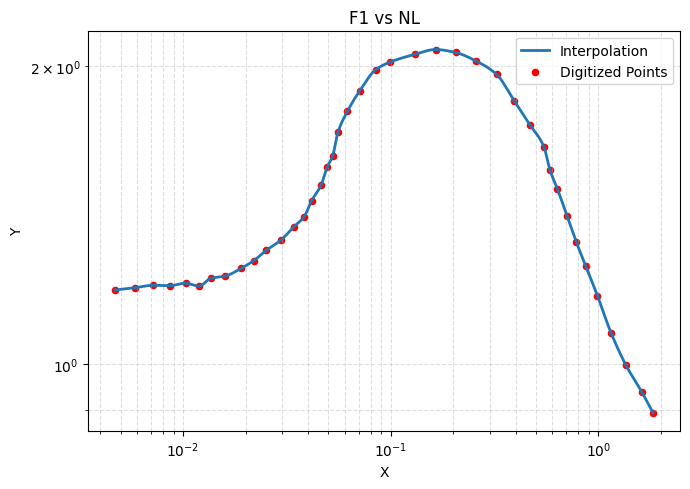

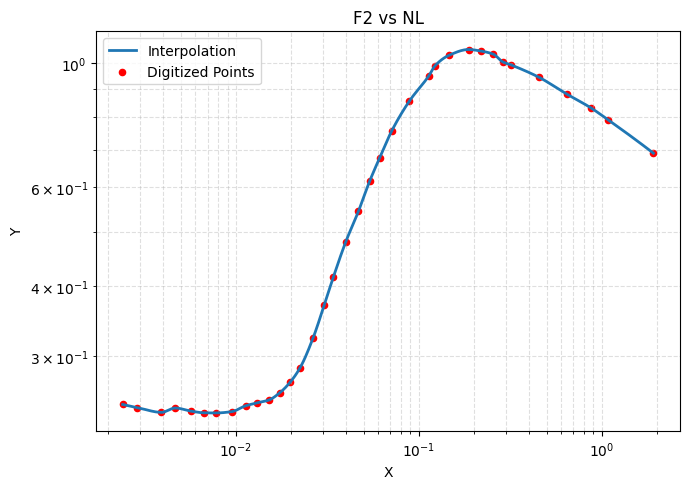

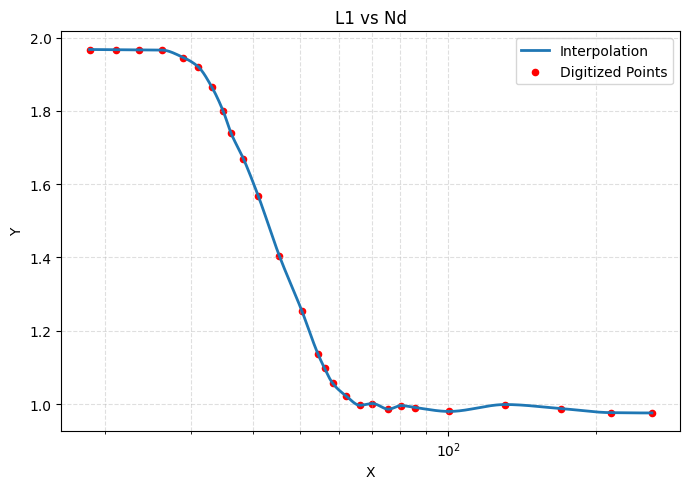

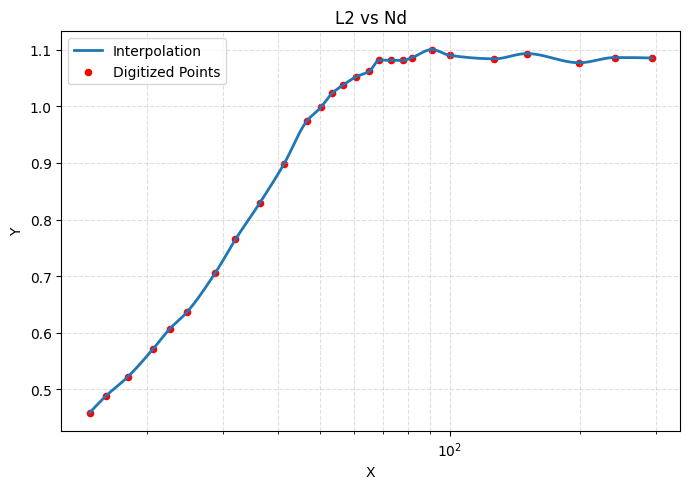

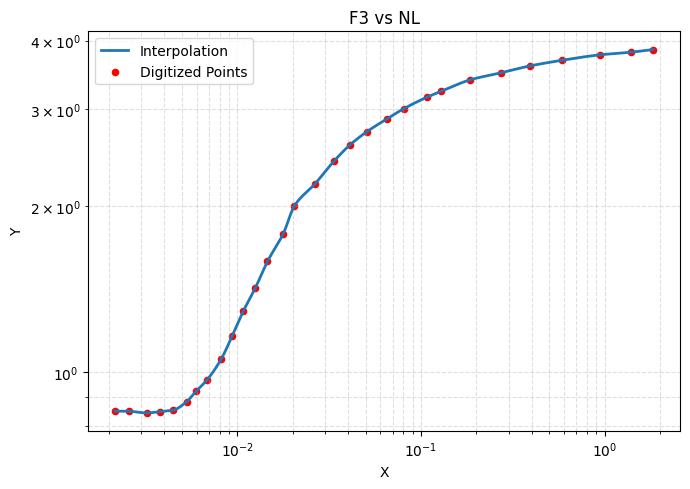

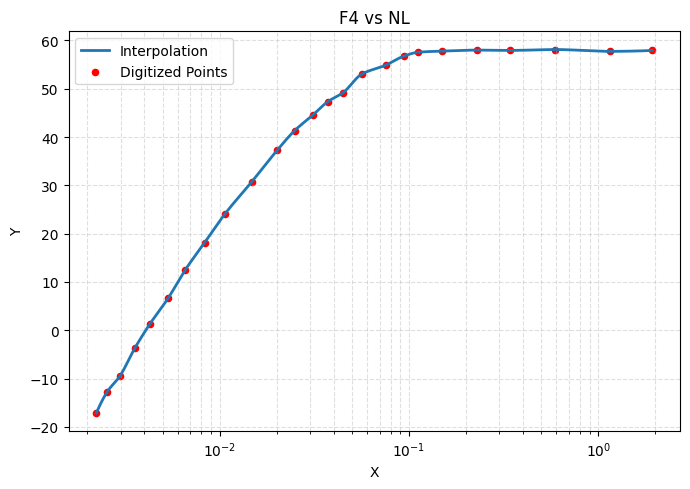

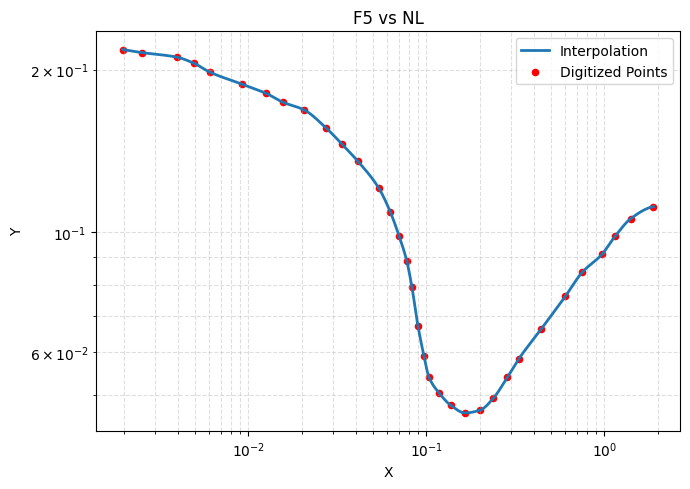

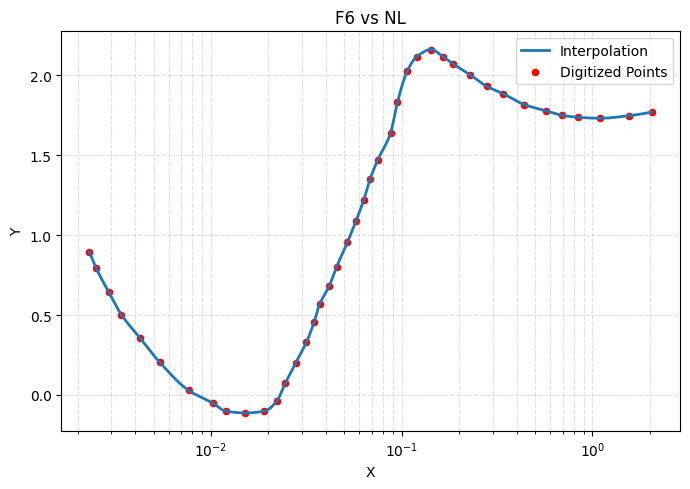

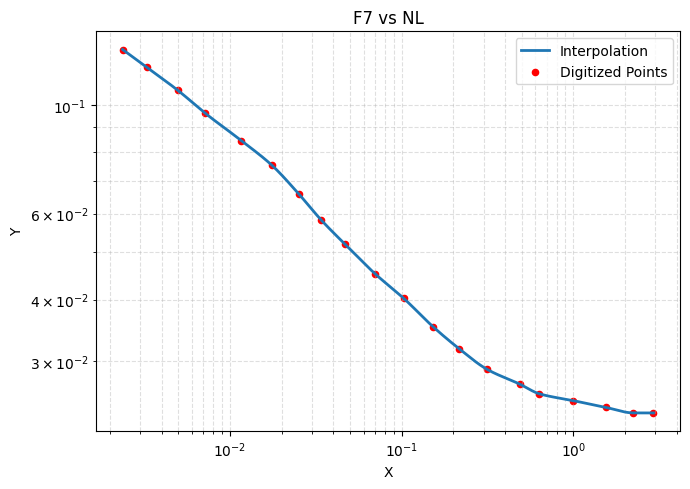

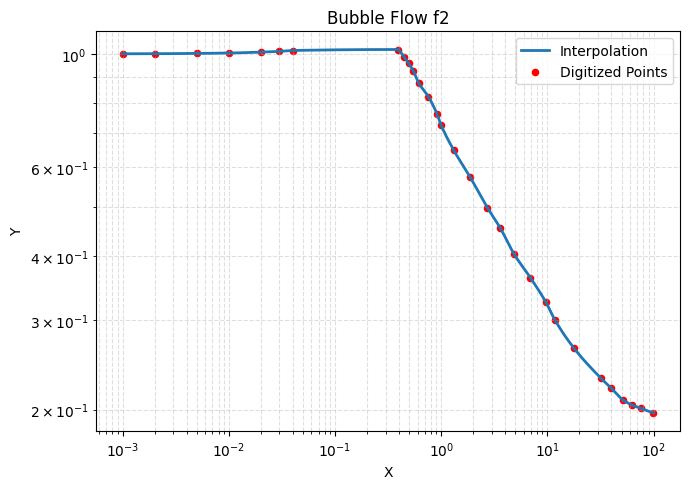

In [10]:
plot_chart(CHART_DATA["F1"])
plot_chart(CHART_DATA["F2"])
plot_chart(CHART_DATA["L1"])
plot_chart(CHART_DATA["L2"])
plot_chart(CHART_DATA["F3"])
plot_chart(CHART_DATA["F4"])
plot_chart(CHART_DATA["F5"])
plot_chart(CHART_DATA["F6"])
plot_chart(CHART_DATA["F7"])
plot_chart(CHART_DATA["Bubble_f2"])

In [3]:
import sys
import os

# --- Start of fix ---
# This block adds the project's root directory (IPM) to the Python path.
# It allows Python to find and import modules from the 'core' directory.
# This version is more robust as it searches for the parent of the 'core' directory.
try:
    # If running as a script, __file__ is defined
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # If running in an interactive console, use current working directory
    current_dir = os.path.abspath('.')

# Traverse up from the current directory to find the project root (which contains 'core')
project_root = current_dir
while not os.path.isdir(os.path.join(project_root, 'core')):
    parent = os.path.dirname(project_root)
    if parent == project_root: # Reached the filesystem root (e.g., C:\)
        raise FileNotFoundError("Could not find the 'core' directory. Make sure you are running this from within the 'IPM' project.")
    project_root = parent

if project_root not in sys.path:
    sys.path.insert(0, project_root)
# --- End of fix ---

from core.vlp import HagedornBrown
from core.pvt import BlackOilPVT

pvt_model = BlackOilPVT(sg_oil=0.806, sg_gas=0.65, sg_water=1.07, watercut=0.05)

Rsb = pvt_model.calc_true_rsb(1579, 314.6)
fp = pvt_model.fluid_properties_dict(P = 242, T= 80, Rsb= Rsb,  producing_gor=474, Pb=1579)

hb_model = HagedornBrown(
    tubing_id=2.441/12,
    tubing_od=2.875/12,
    casing_id=5.55/12,
    roughness=0.0006/12,
    pvt_model=pvt_model,
    fluid_properties=fp,
    watercut=0.05
)

# Note: As before, calculate_pressure_traverse must be called on the instance `hb_model`
# The plot_pressure_traverse method will automatically display the plot.
print("Calculating and plotting pressure traverse...")
hb_model.plot_vlp_curve(
    Pth=242,
    surface_temp=80,
    bottomhole_temp=314.6,
    depth=12119,
    Qmax=1000,
    Qmin=10,
    step_size=50,
)



Calculating and plotting pressure traverse...
Vsg: 0.3107336876661814, Hl: 0.33908988398000134, gor: 62.376411522597834 at depth: 0.0, Ql: 10.0
Vsg: 0.2701326014705609, Hl: 0.37885505037089395, gor: 63.939983571741266 at depth: 50.0, Ql: 10.0
Vsg: 0.26341543972986925, Hl: 0.3859106884923726, gor: 65.6958820316697 at depth: 100.0, Ql: 10.0
Vsg: 0.25689608393917346, Hl: 0.3930049184015849, gor: 67.48636706555743 at depth: 150.0, Ql: 10.0
Vsg: 0.25059361639144007, Hl: 0.4001076725635526, gor: 69.31158465123835 at depth: 200.0, Ql: 10.0
Vsg: 0.2444998495115525, Hl: 0.40721858197065786, gor: 71.1715237930837 at depth: 250.0, Ql: 10.0
Vsg: 0.238606882246352, Hl: 0.4143374048024404, gor: 73.06616523565157 at depth: 300.0, Ql: 10.0
Vsg: 0.23290709545155078, Hl: 0.42146400692744, gor: 74.99548213003948 at depth: 350.0, Ql: 10.0
Vsg: 0.2273931468056186, Hl: 0.4285983446072844, gor: 76.95944061462465 at depth: 400.0, Ql: 10.0
Vsg: 0.22205796526670402, Hl: 0.4357404491964811, gor: 78.9580003191248

c:\Users\Soumik Dutta\Documents\VScode\Petroleum\IPM\core\pvt.py:78: RuntimeWarning: overflow encountered in scalar power
  f = (1.0 + c1*rho_r + c2*(rho_r**2) - c3*(rho_r**5) +
c:\Users\Soumik Dutta\Documents\VScode\Petroleum\IPM\core\pvt.py:79: RuntimeWarning: overflow encountered in scalar multiply
  c4*(rho_r**2)*(1.0 + A11*(rho_r**2))*term_exp - (0.27 * Ppr / (rho_r * Tpr)))
c:\Users\Soumik Dutta\Documents\VScode\Petroleum\IPM\core\pvt.py:79: RuntimeWarning: invalid value encountered in scalar multiply
  c4*(rho_r**2)*(1.0 + A11*(rho_r**2))*term_exp - (0.27 * Ppr / (rho_r * Tpr)))
c:\Users\Soumik Dutta\Documents\VScode\Petroleum\IPM\core\pvt.py:81: RuntimeWarning: overflow encountered in scalar power
  df_drho = (c1 + 2 * c2 * rho_r - 5 * c3 * rho_r**4 +
c:\Users\Soumik Dutta\Documents\VScode\Petroleum\IPM\core\pvt.py:82: RuntimeWarning: overflow encountered in scalar power
  2 * c4 * rho_r * (1 + A11 * rho_r**2 - (A11**2) * rho_r**4) * term_exp +
c:\Users\Soumik Dutta\Documents\V

ValueError: Z-factor solver did not converge. Check input parameters.